In [59]:
import pickle
import pandas as pd
import os
from typing import List

In [60]:
def no_zero(df: pd.DataFrame) -> pd.DataFrame:
    return df[~(df == 0).all(axis=1)]

In [77]:
def concat_df(liste_df: List[pd.DataFrame]) -> pd.DataFrame:
    """
    Prend une liste de DataFrames, supprime la colonne 'Run' de chacun d'eux
    (si elle existe), puis les concatène verticalement.
    """
    dfs_nettoyes = []

    for df in liste_df:
        # On vérifie si la colonne 'Run' existe pour éviter une erreur
        if 'Run' in df.columns:
            # df.drop crée une copie sans la colonne 'Run'
            dfs_nettoyes.append(df.drop(columns=['Run']))
        else:
            # Si la colonne n'existe pas, on garde le df tel quel
            dfs_nettoyes.append(df)

    # Concaténation verticale (axis=0) et réinitialisation de l'index
    df_final = pd.concat(dfs_nettoyes, axis=1)

    return df_final

# 2023

In [6]:
# Définition du dossier
OUTPUT_DIR = '../03_Results'
# Chargement results_wo_peaks_2023_defaut
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2023_defaut.pkl'), 'rb') as f:
    results_wo_peaks_2023_defaut = pickle.load(f)
# Chargement results_wo_peaks_2023
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2023_update.pkl'), 'rb') as f:
    results_wo_peaks_2023_update = pickle.load(f)
# Chargement results_2_peaks_2023
with open(os.path.join(OUTPUT_DIR, 'results_2_peaks_2023.pkl'), 'rb') as f:
    results_2_peaks_2023 = pickle.load(f)
# Chargement results_118_peaks_2023
with open(os.path.join(OUTPUT_DIR, 'results_118_peaks_2023.pkl'), 'rb') as f:
    results_118_peaks_2023 = pickle.load(f)

## Capacité

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_tech_distribution_two_subplots(
    results_peak,
    results_wo_peaks,
    period_labels,
    periods_wo=[1, 2],
    periods_peak=[1, 2, 13, 14]
):
    # ==================================================
    # 1) EXTRACTION DES TECHNOLOGIES ET COEFFICIENTS ELEC
    # ==================================================
    layers = results_peak.parameters["layers_in_out"].drop(columns="Run", errors="ignore")
    is_elec = layers.index.get_level_values(1).str.startswith("ELEC")
    coeff_by_tech = layers[is_elec & (layers > 0).any(axis=1)]["layers_in_out"].groupby(level=0).first()

    # Ressources spécifiques à traiter manuellement
    specific_resources = ["CHURCHILL_FALLS", "ELECTRICITY_EHV", "ELECTRICITY_OTHER"]
    valid_techs = [t for t in coeff_by_tech.index if t not in specific_resources]

    # Mapping de renommage avec agrégation des deux types d'importations
    TECH_LABELS = {
        "GAS_CENTRAL": "Centrale - Gaz",
        "CCGT": "Centrale - Gaz",
        "HYDRO_DAM": "Hydro - Barrage",
        "HYDRO_RIVER": "Hydro - Rivières",
        "PV_ROOF": "PV",
        "PV_GROUND": "PV",
        "WIND_ONSHORE": "Éolien",
        "WIND_OFFSHORE": "Éolien",
        "CHURCHILL_FALLS": "Churchill Falls",
        "ELECTRICITY_EHV": "Autres importations",    # Corrigé pour fusionner correctement avec OTHER
        "ELECTRICITY_OTHER": "Autres importations"
    }

    # ==================================================
    # 2) FONCTION INTERNE SIMPLIFIÉE POUR CONSTRUIRE LE DF
    # ==================================================
    def build_clean_df(results, period_ids):
        f_mult_all = results.variables["F_Mult_t"].drop(columns="Run", errors="ignore")

        # 1. Traitement des technos standards de production
        f_mult = f_mult_all[f_mult_all.index.get_level_values("index0").isin(valid_techs) & (f_mult_all > 0).any(axis=1)]
        f_weighted = f_mult.mul(f_mult.index.get_level_values("index0").map(coeff_by_tech), axis=0)

        df = f_weighted["F_Mult_t"].unstack(level="index1")[period_ids].fillna(0)
        df.columns = [period_labels[i - 1] for i in period_ids]

        # 2. Extraction manuelle des ressources spécifiques
        for res in specific_resources:
            try:
                if res in f_mult_all.index.get_level_values(0):
                    res_data = f_mult_all.loc[res]["F_Mult_t"].reindex(period_ids).fillna(0)
                    df.loc[res] = res_data.values
            except KeyError:
                pass

        # Renommer les index (les doublons "Autres importations" apparaissent ici)
        df = df.rename(index=TECH_LABELS)

        # SOMME DES DOUBLONS : Fusionne "Autres importations" (EHV + OTHER) par le biais de l'index
        df = df.groupby(level=0).sum()

        # 3. SÉPARATION ENTRE LES TECHNOS PRINCIPALES ET LE RESTE ("Other")
        is_main = df.index.isin(TECH_LABELS.values())
        df_main = df[is_main].copy()
        df_other = df[~is_main]

        # Nettoyage des résidus indésirables
        df_other = df_other[~df_other.index.str.startswith("TRAFO") & (~df_other.index.isin(["IND_COGEN_WOOD"]))]

        if not df_other.empty and df_other.sum().sum() > 0:
            df_main.loc["Other"] = df_other.sum(axis=0)

        return df_main

    # ==================================================
    # 3) TRAITEMENT ET ALIGNEMENT DES DEUX DATASETS
    # ==================================================
    df_wo = build_clean_df(results_wo_peaks, periods_wo)
    df_peak = build_clean_df(results_peak, periods_peak)

    # Alignement de l'ordre visuel
    tech_order = list(dict.fromkeys(list(df_wo.index) + list(df_peak.index)))

    # --- MODIFICATION DE L'ORDRE ICI ---
    # Inversion de l'ordre d'insertion pour placer "Autres importations" puis "Churchill Falls" au sommet
    for r_item in ["Churchill Falls", "Autres importations"]:
        if r_item in tech_order:
            tech_order.remove(r_item)
            tech_order.append(r_item)

    df_wo = df_wo.reindex(tech_order).fillna(0)
    df_peak = df_peak.reindex(tech_order).fillna(0)

    # Nettoyage des lignes vides
    non_zero = (df_wo.sum(axis=1) + df_peak.sum(axis=1)) > 0
    df_wo, df_peak = df_wo[non_zero], df_peak[non_zero]
    tech_order = df_wo.index.tolist()

    # ==================================================
    # AFFICHAGE DES DATAFRAMES DANS LA CONSOLE (ORDRE INVERSÉ)
    # ==================================================
    print("\n" + "="*50)
    print(" RÉSULTATS : SANS POINTE")
    print("="*50)
    print(df_wo.round(2))

    print("\n" + "="*50)
    print(" RÉSULTATS : AVEC POINTE")
    print("="*50)
    # Pour éviter d'inonder la console si vous avez 118 colonnes, vous pouvez voir le tableau entier
    print(df_peak.round(2))
    print("="*50 + "\n")

    # ==================================================
    # 4) TRACÉ DES GRAPHIQUES (SUBPLOTS CONFIGURABLES)
    # ==================================================
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if len(tech_order) > len(base_colors):
        base_colors = base_colors * 2

    color_map = {tech: base_colors[i % len(base_colors)] for i, tech in enumerate(tech_order)}
    color_list = [color_map[tech] for tech in tech_order]

    # Ajustement adaptatif de la taille globale si le nombre de barres explose
    fig_width = 10 if df_peak.shape[1] <= 15 else 18

    fig, axes = plt.subplots(
        ncols=2, figsize=(fig_width, 6), sharey=True,
        gridspec_kw={"width_ratios": [df_wo.shape[1], df_peak.shape[1]]}
    )

    # Subplot 1 : Sans pointe
    df_wo.T.plot(kind="bar", stacked=True, ax=axes[0], color=color_list, legend=False)
    axes[0].set_title("Sans pointe", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Puissance [GW]", fontsize=11)
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Subplot 2 : Avec pointe
    df_peak.T.plot(kind="bar", stacked=True, ax=axes[1], color=color_list, legend=False)
    axes[1].set_title(f"Avec pointe", fontsize=12, fontweight="bold")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    # Règle intelligente pour l'axe X : Si trop de barres, on cache les étiquettes pour éviter les superpositions d'écriture
    if df_peak.shape[1] > 15:
        axes[1].get_xaxis().set_visible(False)
        axes[1].set_xlabel("Chronologie des pointes", fontsize=11)
    else:
        axes[1].tick_params(axis="x", rotation=30)

    # Légende unique placée correctement sur le côté droit
    legend_handles = [Patch(facecolor=color_map[tech], label=tech) for tech in tech_order]
    bbox_x = 0.84 if fig_width == 13 else 0.88
    fig.legend(handles=legend_handles, title="Technologies / Contrats", loc="center left", bbox_to_anchor=(bbox_x, 0.5))

    rect_right = 0.82 if fig_width == 13 else 0.86
    plt.tight_layout(rect=[0, 0, rect_right, 1])
    plt.show()


 RÉSULTATS : SANS POINTE
                     Janvier  Février
index0                               
Hydro - Barrage        18.95    18.74
Hydro - Rivières       10.38    10.26
PV                      0.00     0.00
Éolien                  1.39     1.54
Centrale - Gaz          0.00     0.00
Churchill Falls         5.40     4.57
Autres importations     0.00     0.00

 RÉSULTATS : AVEC POINTE
                     Janvier  Février  Pointe - Janvier  Pointe - Février
index0                                                                   
Hydro - Barrage        18.95    18.74             22.33             22.33
Hydro - Rivières       10.38    10.26             13.62             13.62
PV                      0.00     0.00              0.00              0.00
Éolien                  1.39     1.54              0.00              0.00
Centrale - Gaz          0.00     0.00              0.41              0.41
Churchill Falls         5.21     4.27              5.43              5.43
Autres importa

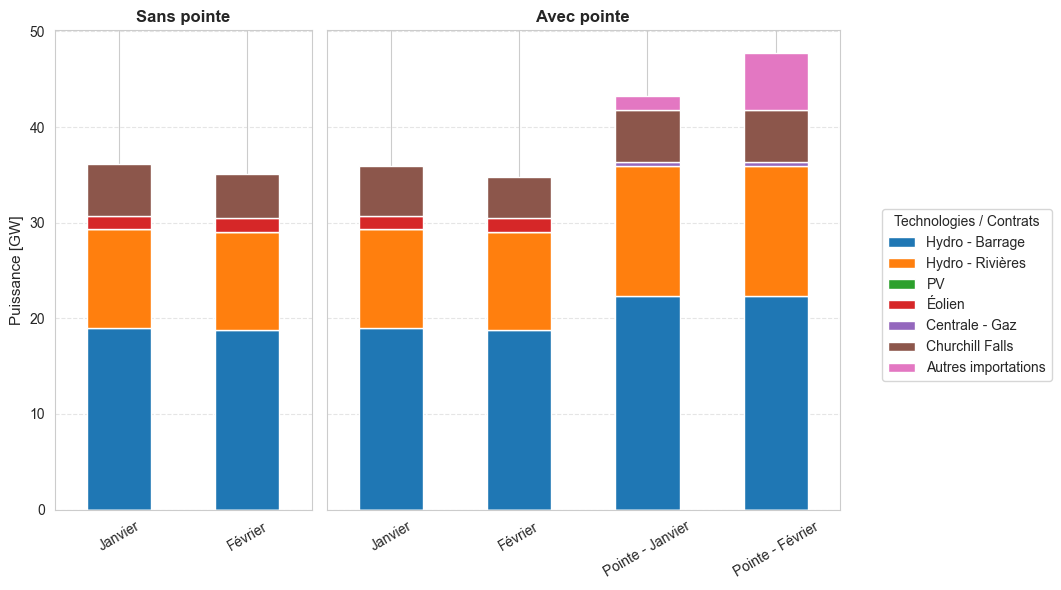

In [8]:
# Exemple de labels pour tes périodes (à adapter selon ton modèle Energyscope)
# Il faut une liste d'au moins 14 éléments puisque periods_peak contient l'ID 14
period_labels = [
    # 1–2 : Janvier–Février
    "Janvier", "Février",

    # 3–12 : autres mois
    "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre",

    # 13–4 : périodes de pointe
    "Pointe - Janvier", "Pointe - Février",
]

# Appel direct de la fonction
plot_tech_distribution_two_subplots(
    results_peak=results_2_peaks_2023,
    results_wo_peaks=results_wo_peaks_2023_update,
    period_labels=period_labels,
    periods_wo=[1, 2],         # Les IDs de périodes à afficher pour le graph "Sans pointe"
    periods_peak=[1, 2, 13, 14] # Les IDs de périodes à afficher pour le graph "Avec pointe"
)


 RÉSULTATS : SANS POINTE
                     Janvier  Février
index0                               
Hydro - Barrage        18.95    18.74
Hydro - Rivières       10.38    10.26
PV                      0.00     0.00
Éolien                  1.39     1.54
Centrale - Gaz          0.00     0.00
Churchill Falls         5.40     4.57
Autres importations     0.00     0.00

 RÉSULTATS : AVEC POINTE
                     Janvier  Février     J1     J2     J3     J4     J5  \
index0                                                                     
Hydro - Barrage        18.95    18.74  22.33  22.33  22.33  22.33  22.33   
Hydro - Rivières       10.38    10.26  13.62  13.62  13.62  13.62  13.62   
PV                      0.00     0.00   0.00   0.00   0.00   0.00   0.00   
Éolien                  1.39     1.54   0.00   0.00   0.00   0.00   0.00   
Centrale - Gaz          0.00     0.00   0.41   0.41   0.41   0.41   0.41   
Churchill Falls         4.80     3.60   5.43   5.43   5.43   5.43   5.43  

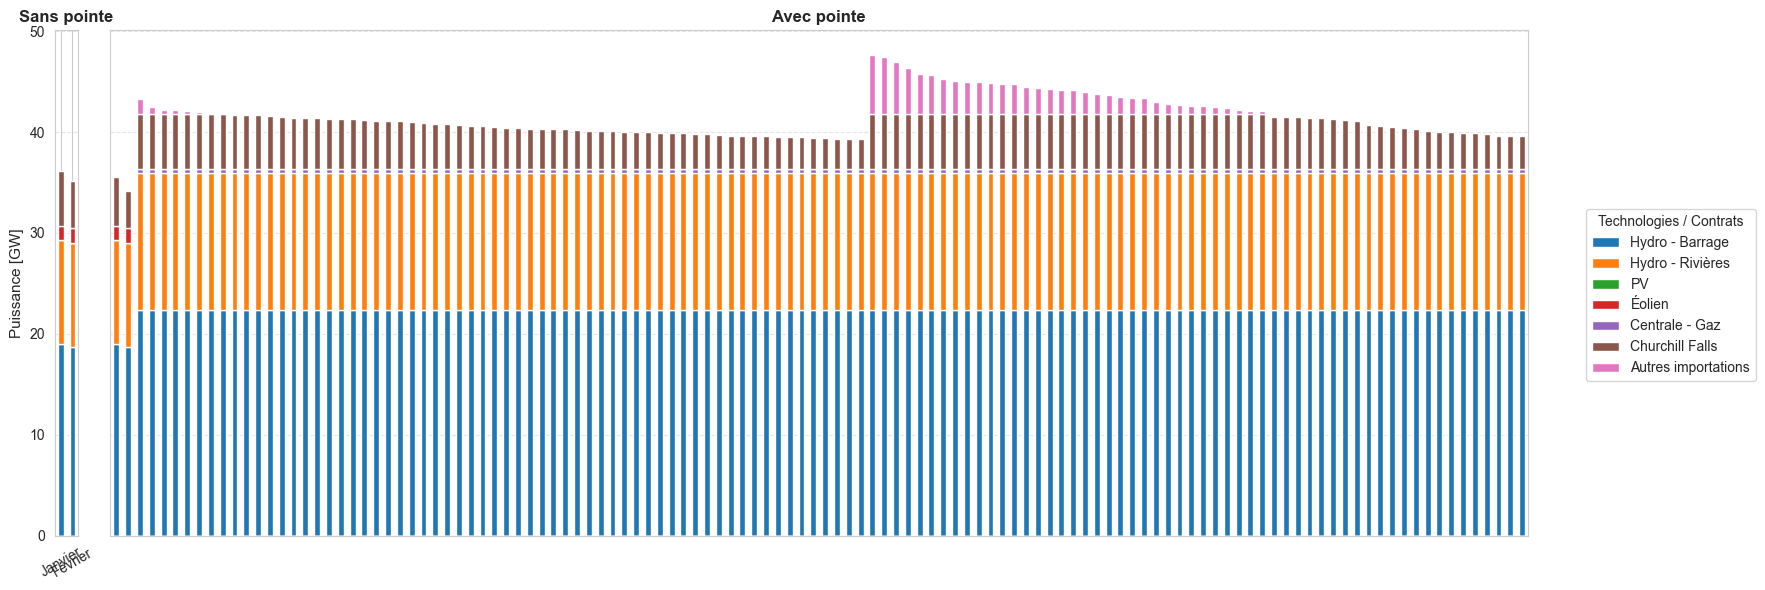

In [9]:
# Exemple de labels pour tes périodes (à adapter selon ton modèle Energyscope)
# Il faut une liste d'au moins 14 éléments puisque periods_peak contient l'ID 14
period_labels = [
    # 1–2 : Janvier–Février
    "Janvier", "Février",

    # 3–12 : autres mois
    "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre",

    # 13–4 : périodes de pointe
    "J1",'J2','J3','J4','J5','J6','J7','J8','J9','J10','J11','J12','J13','J14','J15','J16','J17','J18','J19','J20','J21','J22','J23','J24','J25','J26','J27','J28','J29','J30','J31','J32','J33','J34','J35','J36','J37','J38','J39','J40','J41','J42','J43','J44','J45','J46','J47','J48','J49','J50','J51','J52','J53','J54','J55','J56','J57','J58','J59','J60','J61','J62','F1','F2','F3','F4','F5','F6','F7','F8','F9','F10','F11','F12','F13','F14','F15','F16','F17','F18','F19','F20','F21','F22','F23','F24','F25','F26','F27','F28','F29','F30','F31','F32','F33','F34','F35','F36','F37','F38','F39','F40','F41','F42','F43','F44','F45','F46','F47','F48','F49','F50','F51','F52','F53','F54','F55','F56','F57','F58']

# Appel direct de la fonction
mes_periodes_de_pointe = [1, 2] + list(range(13, 131)) # S'adapte à vos IDs réels dans le modèle

plot_tech_distribution_two_subplots(
    results_peak=results_118_peaks_2023,
    results_wo_peaks=results_wo_peaks_2023_update,
    period_labels=period_labels, # Votre grande liste avec J1...J62, F1...F58
    periods_wo=[1, 2],
    periods_peak=mes_periodes_de_pointe
)

## F_Mult

In [10]:
# F_Mult

# 1. Extraction, nettoyage et renommage de chaque scénario
df_F_Mult_defaut_clean = results_wo_peaks_2023_defaut.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "Default"})
df_F_Mult_update_clean = results_wo_peaks_2023_update.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "Update"})
df_F_Mult_2_peaks_clean = results_2_peaks_2023.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "2 peaks"})
df_F_Mult_118_peaks_clean = results_118_peaks_2023.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "118 peaks"})

# 2. Concaténation horizontale et alignement automatique
df_F_Mult_comparaison = pd.concat([df_F_Mult_defaut_clean, df_F_Mult_update_clean, df_F_Mult_2_peaks_clean, df_F_Mult_118_peaks_clean], axis=1).fillna(0)

# Définition du seuil de tolérance relative (1% de la valeur Default)
seuil_relatif = 0.01 * df_F_Mult_comparaison["Default"]

# Masque : Écart absolu par rapport à Default supérieur au seuil sur au moins une ligne
masque_difference = df_F_Mult_comparaison.sub(df_F_Mult_comparaison["Default"], axis=0).abs().gt(seuil_relatif, axis=0).any(axis=1)

# Application du filtre sur le DataFrame
df_differences_1percent = df_F_Mult_comparaison[masque_difference]
df_differences_1percent

,Default,Update,2 peaks,118 peaks
DEC_BOILER_GAS,4.492532,4.491980,7.622322,7.616298
DEC_BOILER_OIL,1.617809,1.617610,2.744880,2.742711
DEC_BOILER_WOOD,2.220132,2.219859,3.766821,3.763844
DEC_DIRECT_ELEC,13.619467,13.617791,23.107670,23.089408
DEC_HP_ELEC,2.939435,2.939074,4.987237,4.983295
DHN,0.533269,0.533269,0.860429,0.859749
DHN_BOILER_GAS,0.533269,0.533269,0.860429,0.859749
EHV_GRID,35.948127,29.329863,35.948127,35.948127
HV_GRID,30.680583,30.678784,41.857591,41.837987
IND_BOILER_OIL,2.016389,2.016389,5.497166,5.716300


In [11]:
#Annual_Res

# 1. Extraction, nettoyage et renommage de chaque scénario pour Annual_Res
df_Annual_Res_defaut_clean = results_wo_peaks_2023_defaut.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "Default"})
df_Annual_Res_update_clean = results_wo_peaks_2023_update.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "Update"})
df_Annual_Res_2_peaks_clean = results_2_peaks_2023.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "2 peaks"})
df_Annual_Res_118_peaks_clean = results_118_peaks_2023.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "118 peaks"})

# 2. Concaténation horizontale et alignement automatique
df_Annual_Res_comparaison = pd.concat([df_Annual_Res_defaut_clean, df_Annual_Res_update_clean, df_Annual_Res_2_peaks_clean, df_Annual_Res_118_peaks_clean], axis=1).fillna(0)

# 3. Filtrage par écart de plus de 1% par rapport à Default
seuil_relatif = 0.01 * df_Annual_Res_comparaison["Default"]
masque_difference = df_Annual_Res_comparaison.sub(df_Annual_Res_comparaison["Default"], axis=0).abs().gt(seuil_relatif, axis=0).any(axis=1)

df_differences_res_1percent = df_Annual_Res_comparaison[masque_difference]
df_differences_res_1percent

,Default,Update,2 peaks,118 peaks
BIOMASS_FORESTRY_LEFTOVER1,3.538900e+04,35387.776326,35353.533015,3.452773e+04
CO2_E,7.560327e+07,0.000000,0.000000,9.999940e+09
ELECTRICITY_EHV,3.440168e+04,0.000000,0.000000,0.000000e+00
RES_SOLAR,1.359502e+01,13.595016,13.590497,1.342795e+01
RES_WIND_ONSHORE,1.158712e+04,11587.115328,11582.656264,1.141516e+04
CHURCHILL_FALLS,0.000000e+00,28691.806174,28630.715218,2.790391e+04
ELECTRICITY_OTHER,0.000000e+00,5702.813151,5694.559114,5.766591e+03
BIOMASS_FORESTRY_UNEXPLOITED,0.000000e+00,0.000000,25.185526,2.383203e+02
BIOMASS_AGRICULTURE_RESIDUAL,0.000000e+00,0.000000,0.000000,3.669441e+02
BIOMASS_FORESTRY_RESIDUAL,0.000000e+00,0.000000,0.000000,2.457278e+02


In [12]:
# 1. Définition du seuil de tolérance relative (1% de la valeur Default)
seuil_relatif = 0.01 * df_F_Mult_comparaison["Default"]

# 2. Masque : Écart absolu par rapport à Default supérieur au seuil sur au moins une ligne
masque_difference = df_F_Mult_comparaison.sub(df_F_Mult_comparaison["Default"], axis=0).abs().gt(seuil_relatif, axis=0).any(axis=1)

# 3. Application du filtre sur le DataFrame
df_differences_1percent = df_F_Mult_comparaison[masque_difference]
df_differences_1percent

,Default,Update,2 peaks,118 peaks
DEC_BOILER_GAS,4.492532,4.491980,7.622322,7.616298
DEC_BOILER_OIL,1.617809,1.617610,2.744880,2.742711
DEC_BOILER_WOOD,2.220132,2.219859,3.766821,3.763844
DEC_DIRECT_ELEC,13.619467,13.617791,23.107670,23.089408
DEC_HP_ELEC,2.939435,2.939074,4.987237,4.983295
DHN,0.533269,0.533269,0.860429,0.859749
DHN_BOILER_GAS,0.533269,0.533269,0.860429,0.859749
EHV_GRID,35.948127,29.329863,35.948127,35.948127
HV_GRID,30.680583,30.678784,41.857591,41.837987
IND_BOILER_OIL,2.016389,2.016389,5.497166,5.716300


In [13]:
df_F_Mult_t_2_peaks = results_2_peaks_2023.variables['F_Mult_t'].drop(columns=["Run"], errors="ignore").query("F_Mult_t != 0").unstack()
df_F_Mult_t_2_peaks_clean = df_F_Mult_t_2_peaks[~df_F_Mult_t_2_peaks.index.astype(str).str.startswith(("TRUCK",'CAR','BUS','COACH','COMMUTER','LCV','PLANE','JETFUEL','SEMI','SCHOOLBUS','SUV','TRAIN','TRAFO','BULK'))]


df_F_Mult_t_2_peaks_clean.columns = df_F_Mult_t_2_peaks_clean.columns.get_level_values('index1')

df_F_Mult_t_2_peaks_clean[14]

index0
BIOMASS_FORESTRY_LEFTOVER1               NaN
BIOMASS_FORESTRY_LEFTOVER2               NaN
BIOMASS_FORESTRY_UNEXPLOITED    8.661067e+00
BIOMASS_WASTE_BUILDING                   NaN
CCGT                            4.110000e-01
CEMENT                          1.000000e+04
CHURCHILL_FALLS                 5.428000e+00
COAL                            4.333610e-01
CONTAINER                       1.257189e+00
CONTAINER_ELD                   1.257189e+00
DEC_BOILER_GAS                  7.622322e+00
DEC_BOILER_OIL                  2.744880e+00
DEC_BOILER_WOOD                 3.766821e+00
DEC_DIRECT_ELEC                 2.310767e+01
DEC_HP_ELEC                     4.987237e+00
DEC_TH_STORAGE                  2.319940e-02
DHN                             8.604288e-07
DHN_BOILER_GAS                           NaN
DHN_TH_STORAGE                           NaN
DIESEL                          4.091913e+00
EHP_NG_GRID                     9.670442e+00
EHV_GRID                        3.594813e+01
ELE

In [14]:
# 1. Recréer les filtres d'électricité exactement comme dans la fonction
layers = results_2_peaks_2023.parameters["layers_in_out"].drop(columns="Run", errors="ignore")
is_elec = layers.index.get_level_values(1).str.startswith("ELEC")
coeff_by_tech = layers[is_elec & (layers > 0).any(axis=1)]["layers_in_out"].groupby(level=0).first()
valid_techs = coeff_by_tech.index

# 2. Extraire F_Mult_t pour les périodes de pointe
f_mult_all = results_2_peaks_2023.variables["F_Mult_t"].drop(columns="Run", errors="ignore")
f_mult = f_mult_all[f_mult_all.index.get_level_values("index0").isin(valid_techs) & (f_mult_all > 0).any(axis=1)]
f_weighted = f_mult.mul(f_mult.index.get_level_values("index0").map(coeff_by_tech), axis=0)

# 3. Pivoter et filtrer pour ne garder QUE ce qui n'est PAS dans tes TECH_LABELS principaux
periods_peak = [1, 2, 13, 14]  # Tes périodes avec pointe
df_all_techs = f_weighted["F_Mult_t"].unstack(level="index1")[periods_peak].fillna(0)

# Nettoyage initial identique à ton code
df_all_techs = df_all_techs[~df_all_techs.index.str.startswith("TRAFO") & (~df_all_techs.index.isin(["IND_COGEN_WOOD", "ELECTRICITY_EHV"]))]

# Filtrer pour exclure les techs principales connues
known_techs = ["GAS_CENTRAL", "CCGT", "ELECTRICITY_IMPORT", "HYDRO_DAM", "HYDRO_RIVER", "PV", "PV_ROOF", "WIND", "WIND_ONSHORE"]
df_other_hidden = df_all_techs[~df_all_techs.index.isin(known_techs)]

# 4. Afficher le total cumulé sur ces périodes trié par importance
print("--- TECHNOLOGIES CACHÉES DANS 'OTHER' PENDANT LES POINTES ---")
print(df_other_hidden.sum(axis=1).sort_values(ascending=False))

--- TECHNOLOGIES CACHÉES DANS 'OTHER' PENDANT LES POINTES ---
index0
CHURCHILL_FALLS      20.340133
ELECTRICITY_OTHER     7.370322
dtype: float64


In [15]:
# 1. Vérifier si ELECTRICITY_OTHER est traité comme une technologie ou une ressource
print("--- SENS DE PRODUCTION / CONSOMMATION ---")
try:
    # On regarde dans layers_in_out comment ELECTRICITY_OTHER interagit avec l'électricité
    layers_subset = results_2_peaks_2023.parameters["layers_in_out"].xs("ELECTRICITY_OTHER", level=0, drop_level=False)
    print("Coefficients dans layers_in_out pour ELECTRICITY_OTHER :")
    print(layers_subset)
except KeyError:
    print("ELECTRICITY_OTHER n'est pas défini dans les technologies de layers_in_out.")

# 2. Extraction brute de sa production par période de pointe
print("\n--- VALEURS BRUTES PENDANT LES POINTES ---")
try:
    f_mult_other = results_2_peaks_2023.variables["F_Mult_t"].loc["ELECTRICITY_OTHER"]["F_Mult_t"]
    print("Production brute de ELECTRICITY_OTHER aux périodes demandées :")
    print(f_mult_other.loc[[1, 2, 13, 14]])
except KeyError:
    print("Pas de variable F_Mult_t pour ELECTRICITY_OTHER.")

--- SENS DE PRODUCTION / CONSOMMATION ---
Coefficients dans layers_in_out pour ELECTRICITY_OTHER :
                                                 layers_in_out  Run
index0            index1                                           
ELECTRICITY_OTHER ACETIC_ACID                              0.0    0
                  ACETONE                                  0.0    0
                  ALUMINUM                                 0.0    0
                  BENZENE                                  0.0    0
                  BIOMASS_AGRICULTURE_DEJECTION            0.0    0
...                                                        ...  ...
                  WASTE_BIO                                0.0    0
                  WASTE_FOS                                0.0    0
                  WET_BIOMASS                              0.0    0
                  WOOD                                     0.0    0
                  XYLENE                                   0.0    0

[98 rows x 2 col

In [16]:
import pandas as pd

# 1. Extraction des puissances totales sur les périodes de pointe pour comparer les échelles
periods_peak = [1, 2, 13, 14]

# Production cumulée de ELECTRICITY_OTHER sur ces pointes
f_mult_all = results_2_peaks_2023.variables["F_Mult_t"].drop(columns="Run", errors="ignore")
val_other = f_mult_all.loc["ELECTRICITY_OTHER"]["F_Mult_t"].loc[periods_peak]

# Production cumulée d'une techno de référence (ex: HYDRO_DAM) pour voir le ratio d'unité
try:
    val_hydro = f_mult_all.loc["HYDRO_DAM"]["F_Mult_t"].loc[periods_peak]
    comparison_df = pd.DataFrame({"ELECTRICITY_OTHER": val_other, "HYDRO_DAM": val_hydro})

    print("--- COMPARAISON DES ORDRES DE GRANDEUR (VÉRIFICATION UNITÉ) ---")
    print(comparison_df)
    print("\nRatio OTHER / HYDRO :")
    print(val_other / val_hydro.replace(0, 1)) # Évite la division par zéro
except KeyError:
    print("HYDRO_DAM non trouvé, voici les valeurs brutes de ELECTRICITY_OTHER :")
    print(val_other)

--- COMPARAISON DES ORDRES DE GRANDEUR (VÉRIFICATION UNITÉ) ---
        ELECTRICITY_OTHER  HYDRO_DAM
index1                              
1                0.000000  18.950683
2                0.000000  18.739827
13               1.445707  22.331127
14               5.924615  22.331127

Ratio OTHER / HYDRO :
index1
1     0.000000
2     0.000000
13    0.064740
14    0.265307
Name: F_Mult_t, dtype: float64


## Couts

                Sans pointe  2 pointes  118 pointes
Investissement    45.070724  47.699685    47.698535
Maintenance       26.277539  26.560199    26.560393
Opération         28.651737  28.637542    28.197604


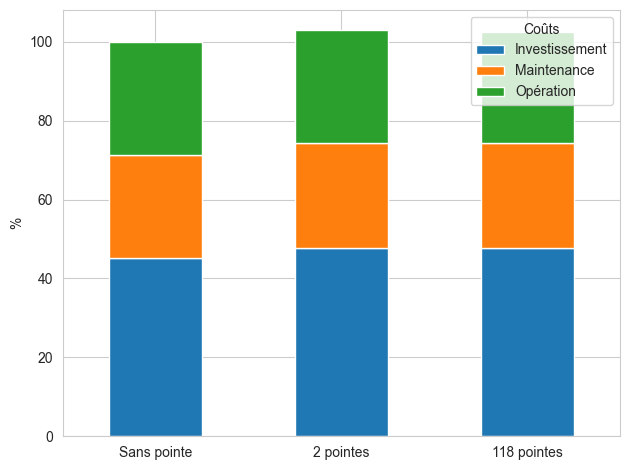

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuration des scénarios à comparer
scenarios = {
    "Sans pointe": results_wo_peaks_2023_update,
    "2 pointes": results_2_peaks_2023,
    "118 pointes": results_118_peaks_2023
}

# 2. Fonction d'extraction et de sommation des coûts
def extraire_couts(res_obj):
    c_inv = pd.Series([res_obj.postprocessing['df_annual']['C_inv_an'].sum()], index=['C_inv'])
    c_maint = res_obj.variables['C_maint'].drop(columns='Run', errors='ignore').sum()
    c_op = res_obj.variables['C_op'].drop(columns='Run', errors='ignore').sum()
    return pd.concat([c_inv, c_maint, c_op])

# 3. Construction vectorisée du DataFrame comparatif
df_couts = pd.DataFrame({nom: extraire_couts(res) for nom, res in scenarios.items()})
df_couts.index = ['Investissement', 'Maintenance', 'Opération']

# 4. Normalisation (%) par rapport au total du scénario de référence choisi
reference = "Sans pointe"
df_couts_norm = df_couts.div(df_couts[reference].sum()) * 100

# 5. Affichage des résultats numériques et génération du graphique
print(df_couts_norm)

df_couts_norm.T.plot(kind="bar", stacked=True)
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(title="Coûts", loc="upper right")
plt.tight_layout()

In [18]:
df_couts_norm.sum()

Sans pointe    100.000000
2 pointes      102.897425
118 pointes    102.456531
dtype: float64

## CO2

In [19]:
results_118_peaks_2023.variables['Total_Emission'].drop(columns='Run').unstack()

KeyError: 'Total_Emission'

            Sans pointe    2 pointes   118 pointes
Total GWP  60154.613987  60146.36265  1.000000e+10


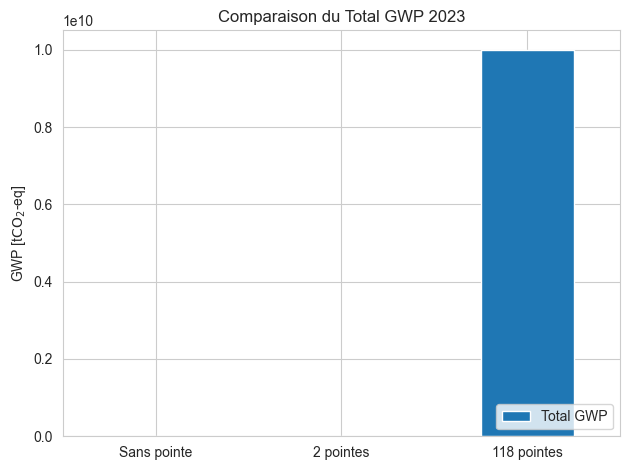

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

scenarios = {
    "Sans pointe": results_wo_peaks_2023_update,
    "2 pointes": results_2_peaks_2023,
    "118 pointes": results_118_peaks_2023
}


# 1. Extraction vectorisée du Total GWP pour chaque scénario
df_gwp = pd.DataFrame({
    nom: [res.variables['TotalGWP'].drop(columns='Run', errors='ignore').values.sum()]
    for nom, res in scenarios.items()
}, index=["Total GWP"])

# 2. Affichage des résultats numériques
print(df_gwp)

# 3. Génération et sauvegarde du graphique comparatif
df_gwp.T.plot(kind="bar")
plt.ylabel("GWP [t$\\text{CO}_2$-eq]")
plt.xticks(rotation=0)
plt.title("Comparaison du Total GWP 2023")
plt.legend(loc="lower right")
plt.tight_layout()

# 2050

In [52]:
# Définition du dossier
OUTPUT_DIR = '../03_Results'
# Chargement
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050.pkl'), 'rb') as f:
    results_wo_peaks_2050 = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050_carboneutre.pkl'), 'rb') as f:
    results_wo_peaks_2050_carboneutre = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050_carboneutre_planHQ.pkl'), 'rb') as f:
    results_wo_peaks_2050_carboneutre_planHQ = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_peaks_2050_carboneutre.pkl'), 'rb') as f:
    results_peaks_2050_carboneutre = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_peaks_2050_carboneutre_planHQ.pkl'), 'rb') as f:
    results_peaks_2050_carboneutre_planHQ = pickle.load(f)


## 2023 VS 2050

### Demande

In [22]:
# 2. Extraction des séries de données
demand_2023_raw = results_wo_peaks_2023_update.parameters['end_uses_demand_year']
demand_2050_raw = results_wo_peaks_2050_carboneutre.parameters['end_uses_demand_year']

s_2023 = demand_2023_raw['value'] if 'value' in demand_2023_raw.columns else demand_2023_raw.iloc[:, 0]
s_2050 = demand_2050_raw['value'] if 'value' in demand_2050_raw.columns else demand_2050_raw.iloc[:, 0]

# 3. Création du DataFrame de base avec les deux colonnes
df_total = pd.DataFrame({
    '2023': s_2023,
    '2050': s_2050
}).fillna(0)

# Donner des noms clairs aux index pour pouvoir les manipuler facilement
df_total.index.names = ['Demand_Type', 'Sector']


# --- COMBINER AGRICULTURE ET INDUSTRY ---
df_total = df_total.reset_index()
df_total['Sector'] = df_total['Sector'].replace('AGRICULTURE', 'INDUSTRY')
df_total = df_total.groupby(['Demand_Type', 'Sector']).sum()


# 4. Traitement spécifique pour mettre EXPORT au niveau 0 et l'enlever du niveau 1

# Étape A : On isole uniquement les lignes où le Secteur est 'EXPORT'
df_exports_only = df_total[df_total.index.get_level_values('Sector') == 'EXPORT'].copy()

# MODIFICATION ICI : On force le niveau 0 à 'ELECTRICITY_EHV' au lieu de 'EXPORT_...'
df_exports_only.index = pd.MultiIndex.from_tuples(
    [('ELECTRICITY_EHV', "Export") for dt, sec in df_exports_only.index],
    names=['Demand_Type', 'Sector']
)

# Comme forcer le nom peut générer des doublons d'index (si vous aviez plusieurs lignes d'exports),
# on applique un groupe par somme pour fusionner d'éventuelles lignes redondantes d'export
df_exports_only = df_exports_only.groupby(['Demand_Type', 'Sector']).sum()


# Étape B : On filtre l'énergie standard (Heat & Electricity) en EXCLUANT les secteurs 'TRANSPORTATION' et 'EXPORT'
df_energy_standard = df_total[
    (df_total.index.get_level_values('Demand_Type').str.contains('HEAT|ELECTRICITY', case=False)) &
    (~df_total.index.get_level_values('Sector').isin(['TRANSPORTATION', 'EXPORT']))
].copy()


# Étape C : On combine les deux parties (Énergie standard + Exports reformatés)
df_compare = pd.concat([df_energy_standard, df_exports_only])

# Optionnel : On ré-applique un groupby au cas où 'ELECTRICITY_EHV' existait déjà dans un autre secteur (par sécurité)
df_compare = df_compare.groupby(['Demand_Type', 'Sector']).sum()

# On trie l'index pour le visuel
df_compare = df_compare.sort_index()

# Optionnel : On retire les lignes qui restent à 0
df_compare = df_compare[(df_compare['2023'] > 0.01) | (df_compare['2050'] > 0.01)]


# Affichage du résultat
print("--- DataFrame de comparaison Énergie (Heat & Electricity) par Secteur ---")
print(df_compare)

--- DataFrame de comparaison Énergie (Heat & Electricity) par Secteur ---
                                2023          2050
Demand_Type     Sector                            
ELECTRICITY_EHV Export      35556.00  35556.000000
                INDUSTRY     7089.69   8153.216673
ELECTRICITY_HV  INDUSTRY    72996.22  83946.406402
ELECTRICITY_LV  HOUSEHOLDS  16235.92  18471.213741
                SERVICES    11233.79  15524.450234
ELECTRICITY_MV  INDUSTRY    13539.30  15272.073719
                SERVICES     3523.39   4869.121882
HEAT_HIGH_T     INDUSTRY    74419.42  85583.101091
                SERVICES     1065.93   1473.053817
HEAT_LOW_T_HW   HOUSEHOLDS  13315.92  15149.200321
                INDUSTRY      741.17    834.092393
                SERVICES     2874.75   3972.738792
HEAT_LOW_T_SC   HOUSEHOLDS   2858.15   3251.648170
                SERVICES     2970.86   4105.557272
HEAT_LOW_T_SH   HOUSEHOLDS  54252.52  61721.780651
                INDUSTRY     4334.70   4820.601431
        

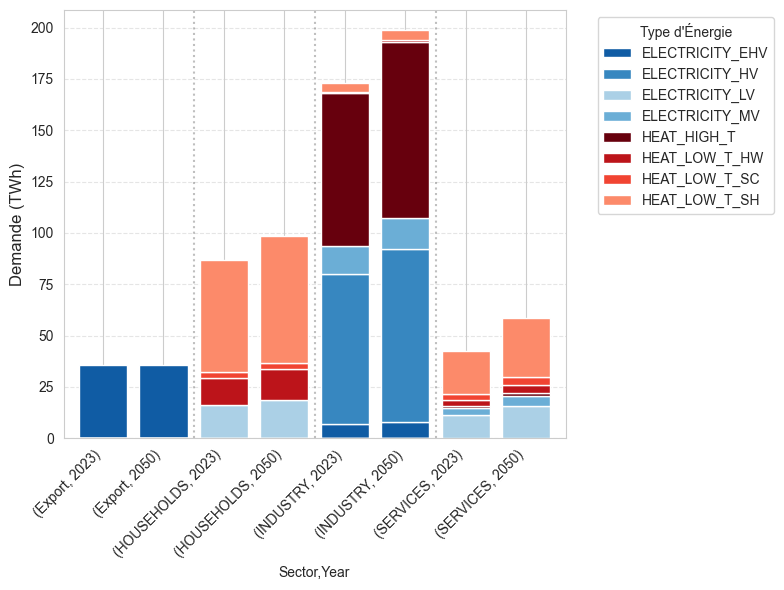

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib  # Ajouté pour accéder directement à matplotlib.colormaps
import numpy as np
import seaborn as sns

# --- Division par 1000 directe ---
df_compare_twh = df_compare / 1000

# 1. On "fond" le DataFrame converti en TWh
df_melted = df_compare_twh.reset_index().melt(
    id_vars=['Demand_Type', 'Sector'],
    value_vars=['2023', '2050'],
    var_name='Year',
    value_name='Demand'
)

# 2. On pivote la table
df_plot = df_melted.pivot(
    index=['Sector', 'Year'],
    columns='Demand_Type',
    values='Demand'
).fillna(0)


# --- NOUVELLE SYNTAXE POUR LES DÉGRADÉS (Sans Warning) ---
heat_cols = [col for col in df_plot.columns if 'HEAT' in col]
# Ordre souhaité
elec_order = ['EHV','HV' ,'MV','LV']

# Recréation des colonnes Electricity dans le bon ordre
elec_cols = []
for lvl in elec_order:
    elec_cols += [col for col in df_plot.columns if ('ELECTRICITY' in col and lvl in col)]
other_cols = [col for col in df_plot.columns if col not in heat_cols and col not in elec_cols]

# Utilisation de la nouvelle syntaxe moderne de Matplotlib (>= 3.7)
color_map_heat = matplotlib.colormaps['Reds'].resampled(max(len(heat_cols) + 2, 5))
color_map_elec = matplotlib.colormaps['Blues'].resampled(max(len(elec_cols) + 2, 5))

color_dict = {}

# Attribution inversée pour le Heat
for idx, col in enumerate(heat_cols):
    factor = 1 - (idx / max(len(heat_cols), 1))
    color_dict[col] = color_map_heat(0.25 + factor * 0.65)

# Attribution inversée pour l'Electricity
for idx, col in enumerate(elec_cols):
    factor = 1 - (idx / max(len(elec_cols), 1))
    color_dict[col] = color_map_elec(0.3 + factor * 0.6)

# Pour les autres colonnes s'il y en a (ex: Export)
if other_cols:
    color_map_other = matplotlib.colormaps['Greys'].resampled(max(len(other_cols), 2))
    for idx, col in enumerate(other_cols):
        factor = 1 - (idx / max(len(other_cols), 1))
        color_dict[col] = color_map_other(0.4 + factor * 0.5)

# On crée la liste finale dans l'ordre exact des colonnes
custom_colors = [color_dict[col] for col in df_plot.columns]


# 3. Génération du graphique en barres empilées (stacked)
ax = df_plot.plot(kind='bar', stacked=True, figsize=(8, 6), color=custom_colors, width=0.8)


# 4. Amélioration visuelle et mise en forme
plt.ylabel("Demande (TWh)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajuster la légende pour qu'elle ne cache pas les barres
handles, labels = ax.get_legend_handles_labels()

# Légende forcée dans le bon ordre
ax.legend(handles, labels,
          title="Type d'Énergie",
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          fontsize=10)

# Améliorer la lisibilité des étiquettes de l'axe X
plt.xticks(rotation=45, ha='right')

# Ajouter des lignes de séparation visuelle entre les secteurs
for i in range(2, len(df_plot), 2):
    plt.axvline(x=i-0.5, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
demand_2023_raw = results_wo_peaks_2023_update.parameters['end_uses_demand_year']
demand_2050_raw = results_wo_peaks_2050_carboneutre.parameters['end_uses_demand_year']

In [25]:
#Transport
# 1. Extraction des séries de données brutes (Pas de division par 1000 ici)
demand_2023_raw = results_wo_peaks_2023_update.parameters['end_uses_demand_year']
demand_2050_raw = results_wo_peaks_2050.parameters['end_uses_demand_year']

s_2023 = demand_2023_raw['value'] if 'value' in demand_2023_raw.columns else demand_2023_raw.iloc[:, 0]
s_2050 = demand_2050_raw['value'] if 'value' in demand_2050_raw.columns else demand_2050_raw.iloc[:, 0]

# 2. Création du DataFrame global de mobilité
df_total = pd.DataFrame({'2023': s_2023, '2050': s_2050}).fillna(0)
df_total.index.names = ['Demand_Type', 'Sector']

df_mobility = df_total[df_total.index.get_level_values('Demand_Type').str.startswith('MOBILITY_')].copy()
df_mobility = df_mobility.groupby('Demand_Type').sum().reset_index()

# Extraction des index demandés
df_mobility['Category'] = df_mobility['Demand_Type'].str.split('_').str[1].str.capitalize()
df_mobility['Distance'] = df_mobility['Demand_Type'].str.split('_').str[2]

df_mobility_final = df_mobility.set_index(['Category', 'Distance']).drop(columns=['Demand_Type']).sort_index()

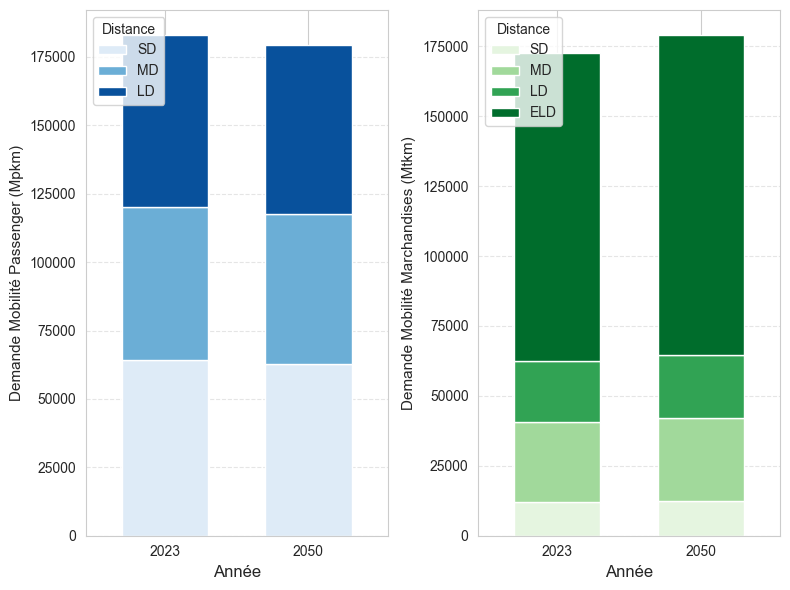

In [26]:
# --- PREPARATION DES DONNÉES POUR LES SUBPLOTS ---

# Extraction et pivot pour Passenger (Index = Année, Colonnes = Distance)
df_passenger = df_mobility_final.loc['Passenger'].T

# Réordonner les colonnes SANS ELD pour Passenger
order_dist_pass = [d for d in ['SD', 'MD', 'LD'] if d in df_passenger.columns]
df_passenger = df_passenger[order_dist_pass]

# Extraction et pivot pour Freight (Index = Année, Colonnes = Distance)
df_freight = df_mobility_final.loc['Freight'].T

# Garder les 4 distances pour Freight
order_dist_freight = [d for d in ['SD', 'MD', 'LD', 'ELD'] if d in df_freight.columns]
df_freight = df_freight[order_dist_freight]


# --- CONFIGURATION DES COULEURS ---

# Dégradé de bleus pour Passenger (3 couleurs maintenant)
custom_colors_pass = [
    "#deebf7",  # bleu très clair
    "#6baed6",  # bleu moyen
    "#08519c"   # bleu foncé
]

# 4 teintes d'une même couleur (ex: palette de verts bien contrastés)
custom_colors_freight = [
    "#e5f5e0",  # très clair
    "#a1d99b",  # clair
    "#31a354",  # moyen
    "#006d2c"   # foncé
]


# --- GÉNÉRATION DU PLOT ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

# Subplot 1 : Passenger (sans ELD)
df_passenger.plot(kind='bar', stacked=True, ax=ax1,
                  color=custom_colors_pass, width=0.6)

ax1.set_ylabel("Demande Mobilité Passenger (Mpkm)", fontsize=11)
ax1.set_xlabel("Année", fontsize=12)
ax1.set_xticklabels(df_passenger.index, rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(title="Distance", loc='upper left')


# Subplot 2 : Freight (4 couleurs distinctes)
df_freight.plot(kind='bar', stacked=True, ax=ax2,
                color=custom_colors_freight, width=0.6)

ax2.set_ylabel("Demande Mobilité Marchandises (Mtkm)", fontsize=11)
ax2.set_xlabel("Année", fontsize=12)
ax2.set_xticklabels(df_freight.index, rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend(title="Distance", loc='upper left')


# Ajustement global
plt.tight_layout()
plt.show()

### Coûts ressources

In [27]:
# 2. Extraction des séries de données c_op brutes
c_op_2023_raw = results_wo_peaks_2023_update.parameters['c_op']
c_op_2050_raw = results_wo_peaks_2050_carboneutre.parameters['c_op']

s_c_op_2023 = c_op_2023_raw['value'] if 'value' in c_op_2023_raw.columns else c_op_2023_raw.iloc[:, 0]
s_c_op_2050 = c_op_2050_raw['value'] if 'value' in c_op_2050_raw.columns else c_op_2050_raw.iloc[:, 0]


# 3. Groupby sur le niveau 0 (Resource) et calcul de la MOYENNE des 12 périodes
s_c_op_2023_mean = s_c_op_2023.groupby(level=0).mean()
s_c_op_2050_mean = s_c_op_2050.groupby(level=0).mean()


# 4. Création du DataFrame de base
df_costs_compare = pd.DataFrame({
    '2023': s_c_op_2023_mean,
    '2050': s_c_op_2050_mean
}).fillna(0)

df_costs_compare.index.name = 'Resource'


# --- FILTRE : RETRAIT DES LIGNES À ZÉRO ET DES LIGNES SANS CHANGEMENT (RATIO = 1) ---
# Condition 1 : Au moins une des deux années doit être strictement supérieure à 0
# Condition 2 : Les valeurs de 2023 et 2050 doivent être différentes (pour éviter un ratio de 1)
df_costs_compare = df_costs_compare[
    ((df_costs_compare['2023'] > 0) | (df_costs_compare['2050'] > 0)) &
    (df_costs_compare['2023'] != df_costs_compare['2050'])
]


# --- CALCUL DU RATIO ET TRI DÉCROISSANT ---

# Calcul du ratio (2050 / 2023)
df_costs_compare['Ratio_2050_2023'] = np.where(
    df_costs_compare['2023'] != 0,
    df_costs_compare['2050'] / df_costs_compare['2023'],
    np.nan
)

# Tri par ordre décroissant selon la colonne 'Ratio_2050_2023'
df_costs_compare = df_costs_compare.sort_values(by='Ratio_2050_2023', ascending=False)


# Affichage du résultat final
print("--- Comparaison des Coûts ---")
df_costs_compare

--- Comparaison des Coûts ---


,2023,2050,Ratio_2050_2023
Resource,,,
CHURCHILL_FALLS,0.020000,0.050000,2.500000
URANIUM,0.005400,0.007903,1.463522
NG_EHP,0.013210,0.018744,1.418890
ELECTRICITY_EHV,0.039855,0.055184,1.384615
LFO,0.074520,0.097263,1.305198
GASOLINE,0.126300,0.164847,1.305198
DIESEL,0.112900,0.147357,1.305198
COAL,0.039900,0.043610,1.092985
BIO_DIESEL,0.250000,0.227669,0.910675


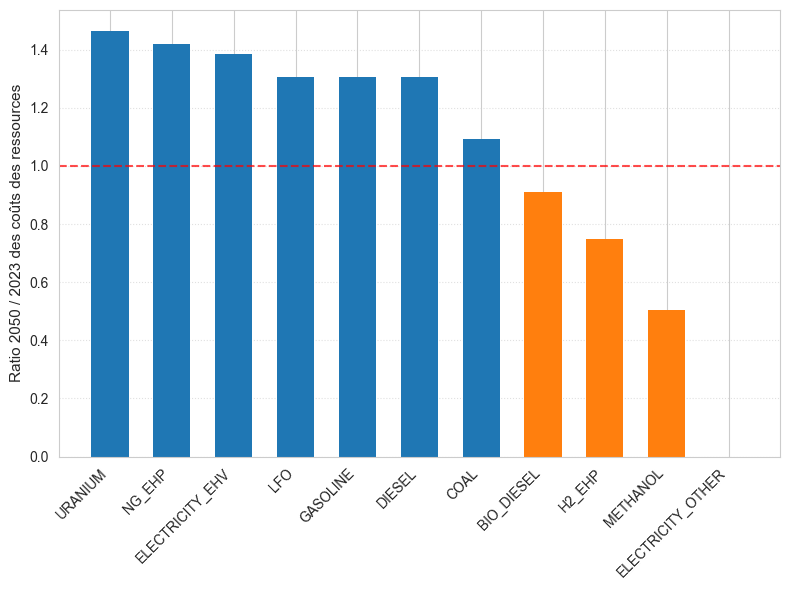

In [28]:
# 1. Préparation des données (on s'assure de ne pas modifier le DF d'origine)
df_plot = df_costs_compare.copy()

# Supprimer la ligne CHURCHILL_FALLS
df_plot = df_plot.drop(index='CHURCHILL_FALLS', errors='ignore')

df_plot = df_plot.dropna(subset=['Ratio_2050_2023'])
df_plot = df_plot.sort_values(by='Ratio_2050_2023', ascending=False)

# 2. Définition des couleurs conditionnelles
# Bleu si le ratio > 1 (augmentation), Orange si le ratio < 1 (diminution)
colors = ['#1f77b4' if r > 1 else '#ff7f0e' for r in df_plot['Ratio_2050_2023']]

# 3. Génération du graphique vertical
plt.figure(figsize=(max(len(df_plot) * 0.4, 8), 6))

bars = plt.bar(df_plot.index, df_plot['Ratio_2050_2023'],
               color=colors, edgecolor='none', width=0.6)

# Ligne de repère horizontale pour le Ratio = 1
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7)

# 4. Habillage
plt.ylabel("Ratio 2050 / 2023 des coûts des ressources", fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

## Scenarios Gaz et capture

In [119]:
# NG
results_wo_peaks_2050_carboneutre.variables['Annual_Res'].loc['NG_EHP']
#results_wo_peaks_2023_update.variables['Annual_Res'].loc['NG_EHP']

#results_peaks_2050_carboneutre.variables['Annual_Res'].loc['NG_EHP']

#results_wo_peaks_2050_carboneutre_planHQ.variables['Annual_Res'].loc['NG_EHP']




Annual_Res    206803.484373
Run                0.000000
Name: NG_EHP, dtype: float64

In [120]:
#Annual_Res
df_2023 = no_zero(results_wo_peaks_2023_update.variables['Annual_Res'])
df1 = no_zero(results_wo_peaks_2050_carboneutre.variables['Annual_Res'])
df2 = no_zero(results_wo_peaks_2050_carboneutre_planHQ.variables['Annual_Res'])
concat_df([df_2023,df1, df2])

,Annual_Res,Annual_Res,Annual_Res
BIOMASS_FORESTRY_LEFTOVER1,35387.776326,42650.000000,42650.000000
BIOMASS_FORESTRY_LEFTOVER2,4007.000000,4007.000000,4007.000000
BIOMASS_WASTE_BUILDING,1955.000000,1955.000000,1955.000000
CHURCHILL_FALLS,28691.806174,50000.000000,50000.000000
COAL,3416.617912,NaN,NaN
DIESEL,35845.157782,NaN,NaN
ELECTRICITY_OTHER,5702.813151,NaN,NaN
GASOLINE,74844.725654,NaN,NaN
HFO,5199.550835,NaN,NaN
JETFUEL,19883.285219,17365.450503,17365.450503


In [121]:
import pandas as pd

# Supprime la limite des lignes, colonnes, et élargit la console
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)  # Évite que les colonnes reviennent à la ligne



In [122]:
#F_Mult
df_2023 = no_zero(results_wo_peaks_2023_update.variables['F_Mult'])
df1 = no_zero(results_wo_peaks_2050_carboneutre.variables['F_Mult'])
df2 = no_zero(results_wo_peaks_2050_carboneutre_planHQ.variables['F_Mult'])
print(concat_df([df_2023,df1, df2]))

                                  F_Mult        F_Mult        F_Mult
BULK_CARRIER                    7.664149           NaN           NaN
BULK_CARRIER_ELD                7.664149           NaN           NaN
BUS_CNG                         0.018012      0.574703      0.574703
BUS_CNG_SD                      0.018012      0.574703      0.574703
BUS_DIESEL                      0.388248           NaN           NaN
BUS_DIESEL_SD                   0.388248           NaN           NaN
BUS_GASOLINE                    0.015113           NaN           NaN
BUS_GASOLINE_SD                 0.015113           NaN           NaN
BUS_HY_DIESEL                   0.166392           NaN           NaN
BUS_HY_DIESEL_SD                0.166392           NaN           NaN
CAR_DIESEL                      1.233454           NaN           NaN
CAR_DIESEL_LD                   0.073329           NaN           NaN
CAR_DIESEL_MD                   0.574201           NaN           NaN
CAR_DIESEL_SD                   0.

In [123]:
#Capture
results_wo_peaks_2050_carboneutre.variables['Annual_Prod'].loc[['DAC_HT', 'DAC_LT', 'CARBON_CAPTURE', 'CARBON_CAPTURE_AMINES', 'CARBON_CAPTURE_MEMBRANES', 'CARBON_CAPTURE_MOF']]


,Annual_Prod,Run
index,,
DAC_HT,0.000000,0
DAC_LT,0.000000,0
CARBON_CAPTURE,0.000000,0
CARBON_CAPTURE_AMINES,0.000000,0
CARBON_CAPTURE_MEMBRANES,33664.653743,0
CARBON_CAPTURE_MOF,0.000000,0


## Scenario sans capture

In [124]:
# Définition du dossier
OUTPUT_DIR = '../03_Results'
# Chargement
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050_carboneutre_limite_CC.pkl'), 'rb') as f:
    results_wo_peaks_2050_carboneutre_limite_CC = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_peaks_2050_carboneutre_limite_CC.pkl'), 'rb') as f:
    results_peaks_2050_carboneutre_limite_CC = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050_carboneutre_limite_CC_HQ.pkl'), 'rb') as f:
    results_wo_peaks_2050_carboneutre_limite_CC_HQ = pickle.load(f)


In [125]:
# NG
df2023 = results_wo_peaks_2023_update.variables['Annual_Res'].loc['NG_EHP']
df1 = results_wo_peaks_2050_carboneutre.variables['Annual_Res'].loc['NG_EHP']
df2 = results_wo_peaks_2050_carboneutre_limite_CC.variables['Annual_Res'].loc['NG_EHP']
df3 = results_peaks_2050_carboneutre_limite_CC.variables['Annual_Res'].loc['NG_EHP']
df4 = results_wo_peaks_2050_carboneutre_limite_CC_HQ.variables['Annual_Res'].loc['NG_EHP']

df2023




Annual_Res    61337.093138
Run               0.000000
Name: NG_EHP, dtype: float64

In [126]:
#Annual_Res
df_2023 = no_zero(results_wo_peaks_2050_carboneutre_limite_CC.variables['Annual_Res'])
df1 = no_zero(results_peaks_2050_carboneutre_limite_CC.variables['Annual_Res'])
df2 = no_zero(results_wo_peaks_2050_carboneutre_limite_CC_HQ.variables['Annual_Res'])
concat_df([df_2023,df1, df2])

,Annual_Res,Annual_Res,Annual_Res
index,,,
BIOMASS_AGRICULTURE_DEJECTION,4149.000000,4149.000000,4149.000000
BIOMASS_AGRICULTURE_RESIDUAL,2251.244945,2293.000000,2251.461615
BIOMASS_FORESTRY_LEFTOVER1,42650.000000,42650.000000,42650.000000
BIOMASS_FORESTRY_LEFTOVER2,4007.000000,4007.000000,4007.000000
BIOMASS_FORESTRY_RESIDUAL,17602.000000,17602.000000,17602.000000
BIOMASS_FORESTRY_UNEXPLOITED,6182.000000,6182.000000,6182.000000
BIOMASS_WASTE_BUILDING,1955.000000,1955.000000,1955.000000
BIOMASS_WASTE_MUNICIPAL,443.000000,443.000000,443.000000
BIOMASS_WASTE_ORGANIC,929.000000,929.000000,929.000000


In [127]:
#Capture
results_wo_peaks_2050_carboneutre_limite_CC.variables['Annual_Prod'].loc[['DAC_HT', 'DAC_LT', 'CARBON_CAPTURE', 'CARBON_CAPTURE_AMINES', 'CARBON_CAPTURE_MEMBRANES', 'CARBON_CAPTURE_MOF']]


,Annual_Prod,Run
index,,
DAC_HT,0.0,0
DAC_LT,0.0,0
CARBON_CAPTURE,0.0,0
CARBON_CAPTURE_AMINES,0.0,0
CARBON_CAPTURE_MEMBRANES,0.0,0
CARBON_CAPTURE_MOF,0.0,0


In [128]:
Tech_elec =    ['HYDRO_DAM', 'HYDRO_RIVER', 'PV_ROOF', 'PV_GROUND', 'WIND_ONSHORE', 'WIND_OFFSHORE']

In [132]:
#F_Mult
df2023 = no_zero(results_wo_peaks_2023_update.variables['F_Mult'].loc[Tech_elec])
df1 = no_zero(results_wo_peaks_2050_carboneutre_limite_CC.variables['F_Mult'].loc[Tech_elec])
df2 = no_zero(results_peaks_2050_carboneutre_limite_CC.variables['F_Mult'].loc[Tech_elec])
df3 = no_zero(results_wo_peaks_2050_carboneutre_limite_CC_HQ.variables['F_Mult'].loc[Tech_elec])
elec = concat_df([df2023,df1, df2, df3])
elec#.sum()

,F_Mult,F_Mult,F_Mult,F_Mult
HYDRO_DAM,26.3570,26.35700,26.357000,26.35700
HYDRO_RIVER,15.1300,15.13000,15.130000,15.13000
PV_ROOF,0.0118,NaN,NaN,0.15000
WIND_ONSHORE,3.9920,54.81225,54.788795,49.37731
PV_GROUND,NaN,NaN,NaN,0.15000


In [130]:
results_peaks_2050_carboneutre_limite_CC.variables['F_Mult_t'].loc[Tech_elec]

F_Mult_t  Run
index0        index1                
HYDRO_DAM     1       18.950683    0
              2       18.739827    0
              3       17.052979    0
              4       13.652926    0
              5       12.071506    0
              6       12.335076    0
              7       13.336642    0
              8       13.231214    0
              9       12.519575    0
              10      11.676151    0
              11      14.549064    0
              12      17.342906    0
              13      21.149793    0
              14      21.387698    0
HYDRO_RIVER   1       10.379180    0
              2       10.258140    0
              3        9.728590    0
              4        8.321500    0
              5        7.443960    0
              6        7.171620    0
              7        7.565000    0
              8        7.580130    0
              9        7.322920    0
              10       6.929540    0
              11       8.351760    0
              12       9.834500    0
              13      13.617000    0
              14      13.617000    0
PV_ROOF       1        0.000000    0
              2        0.000000    0
              3        0.000000    0
              4        0.000000    0
              5        0.000000    0
              6        0.000000    0
              7        0.000000    0
              8        0.000000    0
              9        0.000000    0
              10       0.000000    0
              11       0.000000    0
              12       0.000000    0
              13       0.000000    0
              14       0.000000    0
PV_GROUND     1        0.000000    0
              2        0.000000    0
              3        0.000000    0
              4        0.000000    0
              5        0.000000    0
              6        0.000000    0
              7        0.000000    0
              8        0.000000    0
              9        0.000000    0
              10       0.000000    0
              11       0.000000    0
              12       0.000000    0
              13       0.000000    0
              14       0.000000    0
WIND_ONSHORE  1       19.011712    0
              2       21.093686    0
              3       20.326643    0
              4       19.340445    0
              5       17.039315    0
              6       15.450440    0
              7       13.697199    0
              8       12.546634    0
              9       16.655794    0
              10      19.121289    0
              11      22.299039    0
              12      21.586785    0
              13       0.000000    0
              14       0.000000    0
WIND_OFFSHORE 1        0.000000    0
              2        0.000000    0
              3        0.000000    0
              4        0.000000    0
              5        0.000000    0
              6        0.000000    0
              7        0.000000    0
              8        0.000000    0
              9        0.000000    0
              10       0.000000    0
              11       0.000000    0
              12       0.000000    0
              13       0.000000    0
              14       0.000000    0

## Chaleur

In [26]:
df_layers_in_out = results_wo_peaks_2050_carboneutre.parameters['layers_in_out']
df_layers_in_out = df_layers_in_out[df_layers_in_out['layers_in_out'] != 0].drop(columns='Run')
df_layers_in_out_HEAT_LOW_T = df_layers_in_out[df_layers_in_out.index.get_level_values(1).str.contains('HEAT_LOW_T')]
df_layers_in_out_HEAT_LOW_T
liste_techs_HEAT_LOW_T = df_layers_in_out_HEAT_LOW_T.index.get_level_values(0).tolist()
liste_techs_HEAT_LOW_T

['AFC',
 'ALKALINE_ELECTROLYSIS',
 'AN_DIG_SI',
 'DAC_LT',
 'DEC_ADVCOGEN_H2',
 'DEC_BOILER_BIOGAS',
 'DEC_BOILER_BIOOIL',
 'DEC_BOILER_GAS',
 'DEC_BOILER_OIL',
 'DEC_BOILER_WOOD',
 'DEC_COGEN_BIOGAS',
 'DEC_COGEN_BIOOIL',
 'DEC_COGEN_GAS',
 'DEC_COGEN_OIL',
 'DEC_COGEN_WOOD',
 'DEC_DIRECT_ELEC',
 'DEC_HP_ELEC',
 'DEC_HP_ELEC_PEAK',
 'DEC_HP_ELEC_WINTER',
 'DEC_RENOVATION',
 'DEC_SOLAR',
 'DEC_THHP_BIOGAS',
 'DEC_THHP_GAS',
 'DHN_BOILER_BIOGAS',
 'DHN_BOILER_BIOOIL',
 'DHN_BOILER_GAS',
 'DHN_BOILER_OIL',
 'DHN_BOILER_WOOD',
 'DHN_COGEN_BIOGAS',
 'DHN_COGEN_GAS',
 'DHN_COGEN_WASTE',
 'DHN_COGEN_WASTE_CC',
 'DHN_COGEN_WOOD',
 'DHN_DEEP_GEO',
 'DHN_HP_ELEC',
 'DHN_RENOVATION',
 'FT',
 'H2_EXP_EH_COGEN',
 'H2_EXP_HM_COGEN',
 'H2_EXP_ML_COGEN',
 'HT_LT',
 'HT_LT_DEC',
 'LT_DEC_WH',
 'LT_DHN_WH',
 'NG_EXP_EH',
 'NG_EXP_EH_COGEN',
 'NG_EXP_HM_COGEN',
 'NG_EXP_ML_COGEN',
 'NG_PYROLYSIS_PLASMA',
 'NG_PYROLYSIS_THERMAL',
 'PAFC',
 'PEMFC',
 'PEM_ELECTROLYSIS',
 'SNG_EXP_EH',
 'SNG_EXP_EH_COGEN',

In [27]:
# 1. Ton code d'origine pour extraire et nettoyer les zéros
F_Mult_HEAT_LOW_T = results_wo_peaks_2050_carboneutre.variables['F_Mult'].loc[liste_techs_HEAT_LOW_T]
#F_Mult_HEAT_LOW_T = F_Mult_HEAT_LOW_T[(F_Mult_HEAT_LOW_T != 0).any(axis=1)]

# [MODIFIÉ] 2. Filtrer pour GARDER uniquement les lignes où F_Mult vaut 10000
F_Mult_HEAT_LOW_T = F_Mult_HEAT_LOW_T[F_Mult_HEAT_LOW_T['F_Mult'] != 10000]

# [MODIFIÉ] 2b. Filtrer pour GARDER uniquement les index contenant 'DEC'
# (On a enlevé le "~" pour faire une sélection positive)
F_Mult_HEAT_LOW_T = F_Mult_HEAT_LOW_T[F_Mult_HEAT_LOW_T.index.str.contains('DEC', na=False)]

# 3. Supprimer la colonne 'Run' (si tu veux toujours t'en débarrasser)
F_Mult_HEAT_LOW_T = F_Mult_HEAT_LOW_T.drop(columns=['Run'])

# Afficher le résultat
list(F_Mult_HEAT_LOW_T.index)

['DEC_ADVCOGEN_H2',
 'DEC_BOILER_BIOGAS',
 'DEC_BOILER_BIOOIL',
 'DEC_BOILER_GAS',
 'DEC_BOILER_OIL',
 'DEC_BOILER_WOOD',
 'DEC_COGEN_BIOGAS',
 'DEC_COGEN_BIOOIL',
 'DEC_COGEN_GAS',
 'DEC_COGEN_OIL',
 'DEC_COGEN_WOOD',
 'DEC_DIRECT_ELEC',
 'DEC_HP_ELEC',
 'DEC_HP_ELEC_PEAK',
 'DEC_HP_ELEC_WINTER',
 'DEC_SOLAR',
 'DEC_THHP_BIOGAS',
 'DEC_THHP_GAS',
 'HT_LT_DEC']

## Capacité

### Électricité

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_tech_elec_distribution_five_subplots(
    res_2023,
    res_wo_carb,
    res_wo_carb_hq,
    res_peak_carb,
    res_peak_carb_hq,
    period_labels,
    periods_wo=[1, 2],
    periods_peak=[1, 2, 13, 14]
):
    # ==================================================
    # MAPPING DES ÉTIQUETTES DE PÉRIODES (Noms personnalisés)
    # ==================================================
    LABEL_MAPPING = {
        "P1": "Jan",
        "P2": "Fev",
        "P13": "Pointe jan",
        "P14": "Pointe fev"
    }

    # ==================================================
    # 1) EXTRACTION DES TECHNOLOGIES ET COEFFICIENTS ELEC
    # ==================================================
    layers = res_wo_carb.parameters["layers_in_out"].drop(columns="Run", errors="ignore")
    is_elec = layers.index.get_level_values(1).str.startswith("ELEC")
    coeff_by_tech = layers[is_elec & (layers > 0).any(axis=1)]["layers_in_out"].groupby(level=0).first()

    specific_resources = ["CHURCHILL_FALLS", "ELECTRICITY_EHV", "ELECTRICITY_OTHER"]
    valid_techs = [t for t in coeff_by_tech.index if t not in specific_resources]

    # Mapping de renommage des technologies
    TECH_LABELS = {
        "GAS_CENTRAL": "Centrale - Gaz",
        "CCGT": "Centrale - Gaz",
        "HYDRO_DAM": "Hydro - Barrage",
        "NEW_HYDRO_DAM": "Hydro - Barrage",
        "HYDRO_RIVER": "Hydro - Rivières",
        "NEW_HYDRO_RIVER": "Hydro - Rivières",
        "PV_ROOF": "PV",
        "PV_GROUND": "PV",
        "WIND_ONSHORE": "Éolien",
        "WIND_OFFSHORE": "Éolien",
        "AFC": "Hydrogène",
        "PEMFC": "Hydrogène",
        "SOFC": "Hydrogène",
        "CHURCHILL_FALLS": "Churchill Falls",
        "ELECTRICITY_EHV": "Autres importations",
        "ELECTRICITY_OTHER": "Autres importations"
    }

    # ==================================================
    # 2) FONCTION INTERNE POUR CONSTRUIRE LE DF + DETECTER "OTHER"
    # ==================================================
    def build_clean_df(results, period_ids, scenario_name="Scénario"):
        f_mult_all = results.variables["F_Mult_t"].drop(columns="Run", errors="ignore")

        # 1. Traitement des technos standards de production
        f_mult = f_mult_all[f_mult_all.index.get_level_values("index0").isin(valid_techs) & (f_mult_all > 0).any(axis=1)]
        f_weighted = f_mult.mul(f_mult.index.get_level_values("index0").map(coeff_by_tech), axis=0)

        df = f_weighted["F_Mult_t"].unstack(level="index1")[period_ids].fillna(0)

        # Génération des colonnes d'origine (ex: P1, P2...)
        raw_cols = [period_labels[i - 1] for i in period_ids]
        # Application du renommage personnalisé (Jan, Fev...) avec valeur par défaut si non trouvé
        df.columns = [LABEL_MAPPING.get(col, col) for col in raw_cols]

        # 2. Extraction manuelle des ressources spécifiques
        for res in specific_resources:
            try:
                if res in f_mult_all.index.get_level_values(0):
                    res_data = f_mult_all.loc[res]["F_Mult_t"].reindex(period_ids).fillna(0)
                    df.loc[res] = res_data.values
            except KeyError:
                pass

        # Renommer les index et fusionner les doublons
        df = df.rename(index=TECH_LABELS)
        df = df.groupby(level=0).sum()

        # 3. Séparation entre les technos principales et le reste ("Other")
        is_main = df.index.isin(TECH_LABELS.values())
        df_main = df[is_main].copy()
        df_other = df[~is_main]

        # Nettoyage des résidus indésirables
        df_other = df_other[~df_other.index.str.startswith("TRAFO") & (~df_other.index.isin(["IND_COGEN_WOOD"]))]

        return df_main

    # ==================================================
    # 3) TRAITEMENT ET ALIGNEMENT DES 5 DATASETS
    # ==================================================

    df_0 = build_clean_df(res_2023, periods_wo, "Référence - 2023")
    df_2 = build_clean_df(res_wo_carb, periods_wo, "Carboneutre 2050 - Sans pointe")
    df_3 = build_clean_df(res_wo_carb_hq, periods_wo, "Carboneutre + HQ 2050 - Sans pointe")
    df_4 = build_clean_df(res_peak_carb, periods_peak, "Carboneutre 2050 - Avec pointe")
    df_5 = build_clean_df(res_peak_carb_hq, periods_peak, "Carboneutre + HQ 2050 - Avec pointe")

    # Récupérer l'univers complet de toutes les technologies
    all_dfs = [df_0, df_2, df_3, df_4, df_5]
    tech_order = list(dict.fromkeys([idx for frame in all_dfs for idx in frame.index]))

    # Réorganisation visuelle (Contrats / Imports au sommet de la pile)
    for r_item in ["Churchill Falls", "Autres importations"]:
        if r_item in tech_order:
            tech_order.remove(r_item)
            tech_order.append(r_item)

    # Réindexation globale
    df_0 = df_0.reindex(tech_order).fillna(0)
    df_2 = df_2.reindex(tech_order).fillna(0)
    df_3 = df_3.reindex(tech_order).fillna(0)
    df_4 = df_4.reindex(tech_order).fillna(0)
    df_5 = df_5.reindex(tech_order).fillna(0)

    # Nettoyage des lignes entièrement à 0 partout
    total_sum = df_0.sum(axis=1) + df_2.sum(axis=1) + df_3.sum(axis=1) + df_4.sum(axis=1) + df_5.sum(axis=1)
    non_zero = total_sum > 0

    df_0, df_2, df_3, df_4, df_5 = df_0[non_zero], df_2[non_zero], df_3[non_zero], df_4[non_zero], df_5[non_zero]
    tech_order = df_0.index.tolist()

    # ==================================================
    # 4) CONFIGURATION DES COULEURS ET DE LA FIGURE
    # ==================================================
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if len(tech_order) > len(base_colors):
        base_colors = base_colors * 2

    color_map = {tech: base_colors[i % len(base_colors)] for i, tech in enumerate(tech_order)}
    color_list = [color_map[tech] for tech in tech_order]

    # Ajustement des ratios de largeur (5 éléments désormais)
    width_ratios = [df_0.shape[1], df_2.shape[1], df_3.shape[1], df_4.shape[1], df_5.shape[1]]

    fig, axes = plt.subplots(
        ncols=5, figsize=(10, 6), sharey=True,
        gridspec_kw={"width_ratios": width_ratios}
    )

    scenarios_config = [
        {"df": df_0, "title": "Référence\n(2023)"},
        {"df": df_2, "title": "Carboneutre\n(Sans pointe)"},
        {"df": df_3, "title": "Carboneutre + HQ\n(Sans pointe)"},
        {"df": df_4, "title": "Carboneutre\n(Avec pointe)"},
        {"df": df_5, "title": "Carboneutre + HQ\n(Avec pointe)"}
    ]

    for idx, config in enumerate(scenarios_config):
        ax = axes[idx]
        config["df"].T.plot(kind="bar", stacked=True, ax=ax, color=color_list, legend=False)

        ax.set_title(config["title"], fontsize=9, fontweight="bold")
        ax.tick_params(axis="x", rotation=30, labelsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if idx == 0:
            ax.set_ylabel("Puissance [GW]", fontsize=11, fontweight="bold")

    legend_handles = [Patch(facecolor=color_map[tech], label=tech) for tech in tech_order]
    fig.legend(handles=legend_handles, title="Technologies / Contrats", loc="center left", bbox_to_anchor=(0.89, 0.5))

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

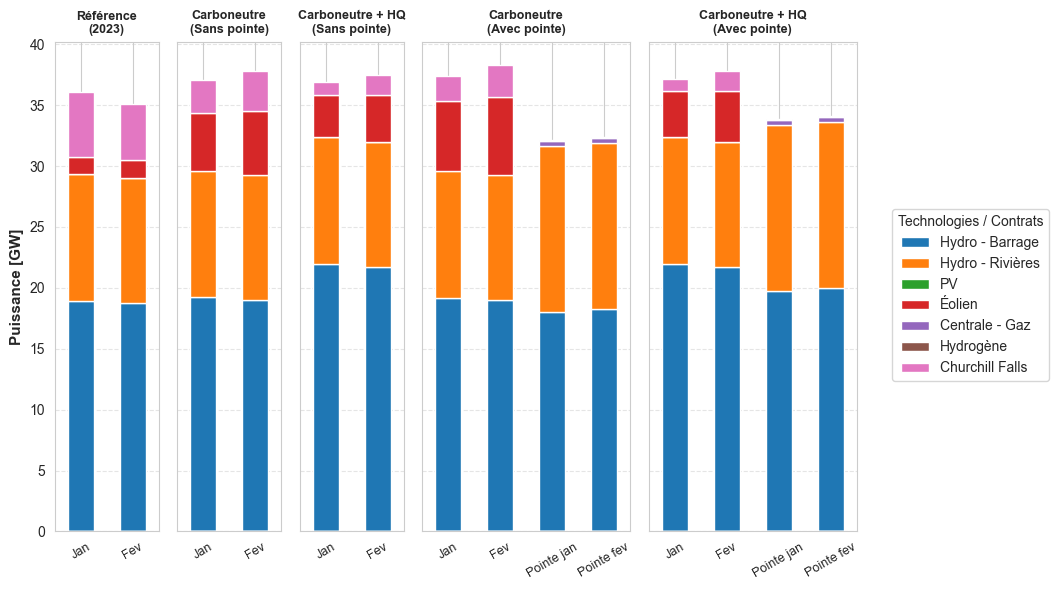

In [31]:
plot_tech_elec_distribution_five_subplots(
    res_2023=results_wo_peaks_2023_update,
    res_wo_carb=results_wo_peaks_2050_carboneutre,
    res_wo_carb_hq=results_wo_peaks_2050_carboneutre_planHQ,
    res_peak_carb=results_peaks_2050_carboneutre,
    res_peak_carb_hq=results_peaks_2050_carboneutre_planHQ,
    period_labels=[f"P{i}" for i in range(1, 15)],
    periods_wo=[1, 2],
    periods_peak=[1, 2, 13, 14]
)

### DEC

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_tech_DEC_distribution_five_subplots(
    res_2023,
    res_wo_carb,
    res_wo_carb_hq,
    res_peak_carb,
    res_peak_carb_hq,
    period_labels,
    periods_wo=[1, 2],
    periods_peak=[1, 2, 13, 14]
):
    # ==================================================
    # MAPPING DES ÉTIQUETTES DE PÉRIODES (Noms personnalisés)
    # ==================================================
    LABEL_MAPPING = {
        "P1": "Jan",
        "P2": "Fev",
        "P13": "Pointe jan",
        "P14": "Pointe fev"
    }

    # ==================================================
    # 1) LISTE DES TECHNOLOGIES CIBLES (DEC) ET RENOMMAGE
    # ==================================================
    valid_techs = [
        'DEC_ADVCOGEN_H2', 'DEC_BOILER_BIOGAS', 'DEC_BOILER_BIOOIL', 'DEC_BOILER_GAS',
        'DEC_BOILER_OIL', 'DEC_BOILER_WOOD', 'DEC_COGEN_BIOGAS', 'DEC_COGEN_BIOOIL',
        'DEC_COGEN_GAS', 'DEC_COGEN_OIL', 'DEC_COGEN_WOOD', 'DEC_DIRECT_ELEC',
        'DEC_HP_ELEC', 'DEC_HP_ELEC_PEAK', 'DEC_HP_ELEC_WINTER', 'DEC_SOLAR',
        'DEC_THHP_BIOGAS', 'DEC_THHP_GAS', 'HT_LT_DEC'
    ]

    # Mapping de renommage pour le graphique
    TECH_LABELS = {
        "DEC_ADVCOGEN_H2": "Cogénération avancée H2",
        "DEC_BOILER_BIOGAS": "Chaudière Biogaz",
        "DEC_BOILER_BIOOIL": "Chaudière Biofuel",
        "DEC_BOILER_GAS": "Chaudière Gaz",
        "DEC_BOILER_OIL": "Chaudière Mazout",
        "DEC_BOILER_WOOD": "Chaudière Bois",
        "DEC_COGEN_BIOGAS": "Cogénération Biogaz",
        "DEC_COGEN_BIOOIL": "Cogénération Biofuel",
        "DEC_COGEN_GAS": "Cogénération Gaz",
        "DEC_COGEN_OIL": "Cogénération Mazout",
        "DEC_COGEN_WOOD": "Cogénération Bois",
        "DEC_DIRECT_ELEC": "Chauffage électrique direct",
        "DEC_HP_ELEC": "Pompe à chaleur (PAC)",
        "DEC_HP_ELEC_PEAK": "Pompe à chaleur (PAC)",
        "DEC_HP_ELEC_WINTER": "Pompe à chaleur (PAC)",
        "DEC_SOLAR": "Solaire thermique",
        "DEC_THHP_BIOGAS": "PAC thermique Biogaz",
        "DEC_THHP_GAS": "PAC thermique Gaz",
        "HT_LT_DEC": "Réseau de chaleur (HT_LT_DEC)"
    }

    # ==================================================
    # 2) FONCTION INTERNE POUR CONSTRUIRE LE DF
    # ==================================================
    def build_clean_df(results, period_ids, scenario_name="Scénario"):
        f_mult_all = results.variables["F_Mult_t"].drop(columns="Run", errors="ignore")

        # Sélectionner uniquement les technos de la liste qui ont des valeurs > 0
        f_mult = f_mult_all[f_mult_all.index.get_level_values("index0").isin(valid_techs) & (f_mult_all > 0).any(axis=1)]

        # Unstack direct sans multiplication par un coefficient électrique
        df = f_mult["F_Mult_t"].unstack(level="index1")[period_ids].fillna(0)

        # Génération et renommage des colonnes d'origine (ex: P1, P2...)
        raw_cols = [period_labels[i - 1] for i in period_ids]
        df.columns = [LABEL_MAPPING.get(col, col) for col in raw_cols]

        # Renommer les index selon le dictionnaire et fusionner les doublons (ex: regrouper les PAC)
        df = df.rename(index=TECH_LABELS)
        df = df.groupby(level=0).sum()

        return df

    # ==================================================
    # 3) TRAITEMENT ET ALIGNEMENT DES 5 DATASETS
    # ==================================================
    df_0 = build_clean_df(res_2023, periods_wo, "Référence - 2023")
    df_2 = build_clean_df(res_wo_carb, periods_wo, "Carboneutre 2050 - Sans pointe")
    df_3 = build_clean_df(res_wo_carb_hq, periods_wo, "Carboneutre + HQ 2050 - Sans pointe")
    df_4 = build_clean_df(res_peak_carb, periods_peak, "Carboneutre 2050 - Avec pointe")
    df_5 = build_clean_df(res_peak_carb_hq, periods_peak, "Carboneutre + HQ 2050 - Avec pointe")

    # Récupérer l'univers complet de toutes les technologies présentes
    all_dfs = [df_0, df_2, df_3, df_4, df_5]
    tech_order = list(dict.fromkeys([idx for frame in all_dfs for idx in frame.index]))

    # Réindexation globale pour aligner toutes les technologies
    df_0 = df_0.reindex(tech_order).fillna(0)
    df_2 = df_2.reindex(tech_order).fillna(0)
    df_3 = df_3.reindex(tech_order).fillna(0)
    df_4 = df_4.reindex(tech_order).fillna(0)
    df_5 = df_5.reindex(tech_order).fillna(0)

    # Nettoyage des lignes entièrement à 0 partout
    total_sum = df_0.sum(axis=1) + df_2.sum(axis=1) + df_3.sum(axis=1) + df_4.sum(axis=1) + df_5.sum(axis=1)
    non_zero = total_sum > 0

    df_0, df_2, df_3, df_4, df_5 = df_0[non_zero], df_2[non_zero], df_3[non_zero], df_4[non_zero], df_5[non_zero]
    tech_order = df_0.index.tolist()

    # ==================================================
    # 4) CONFIGURATION DES COULEURS ET DE LA FIGURE
    # ==================================================
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if len(tech_order) > len(base_colors):
        base_colors = base_colors * 3  # Augmentation du pool de couleurs au besoin

    color_map = {tech: base_colors[i % len(base_colors)] for i, tech in enumerate(tech_order)}
    color_list = [color_map[tech] for tech in tech_order]

    # Ratios de largeur des subplots basés sur le nombre de périodes du sous-graphique
    width_ratios = [df_0.shape[1], df_2.shape[1], df_3.shape[1], df_4.shape[1], df_5.shape[1]]

    fig, axes = plt.subplots(
        ncols=5, figsize=(18, 6), sharey=True,
        gridspec_kw={"width_ratios": width_ratios}
    )

    scenarios_config = [
        {"df": df_0, "title": "Référence\n(2023)"},
        {"df": df_2, "title": "Carboneutre\n(Sans pointe)"},
        {"df": df_3, "title": "Carboneutre + HQ\n(Sans pointe)"},
        {"df": df_4, "title": "Carboneutre\n(Avec pointe)"},
        {"df": df_5, "title": "Carboneutre + HQ\n(Avec pointe)"}
    ]

    for idx, config in enumerate(scenarios_config):
        ax = axes[idx]
        config["df"].T.plot(kind="bar", stacked=True, ax=ax, color=color_list, legend=False)

        ax.set_title(config["title"], fontsize=9, fontweight="bold")
        ax.tick_params(axis="x", rotation=30, labelsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if idx == 0:
            # Remplacement de "Puissance [GW]" par "F_Mult_t" (ou l'unité thermique correspondante de ton modèle)
            ax.set_ylabel("F_Mult_t", fontsize=11, fontweight="bold")

    legend_handles = [Patch(facecolor=color_map[tech], label=tech) for tech in tech_order]
    fig.legend(handles=legend_handles, title="Technologies décentralisées (DEC)", loc="center left", bbox_to_anchor=(0.89, 0.5))

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

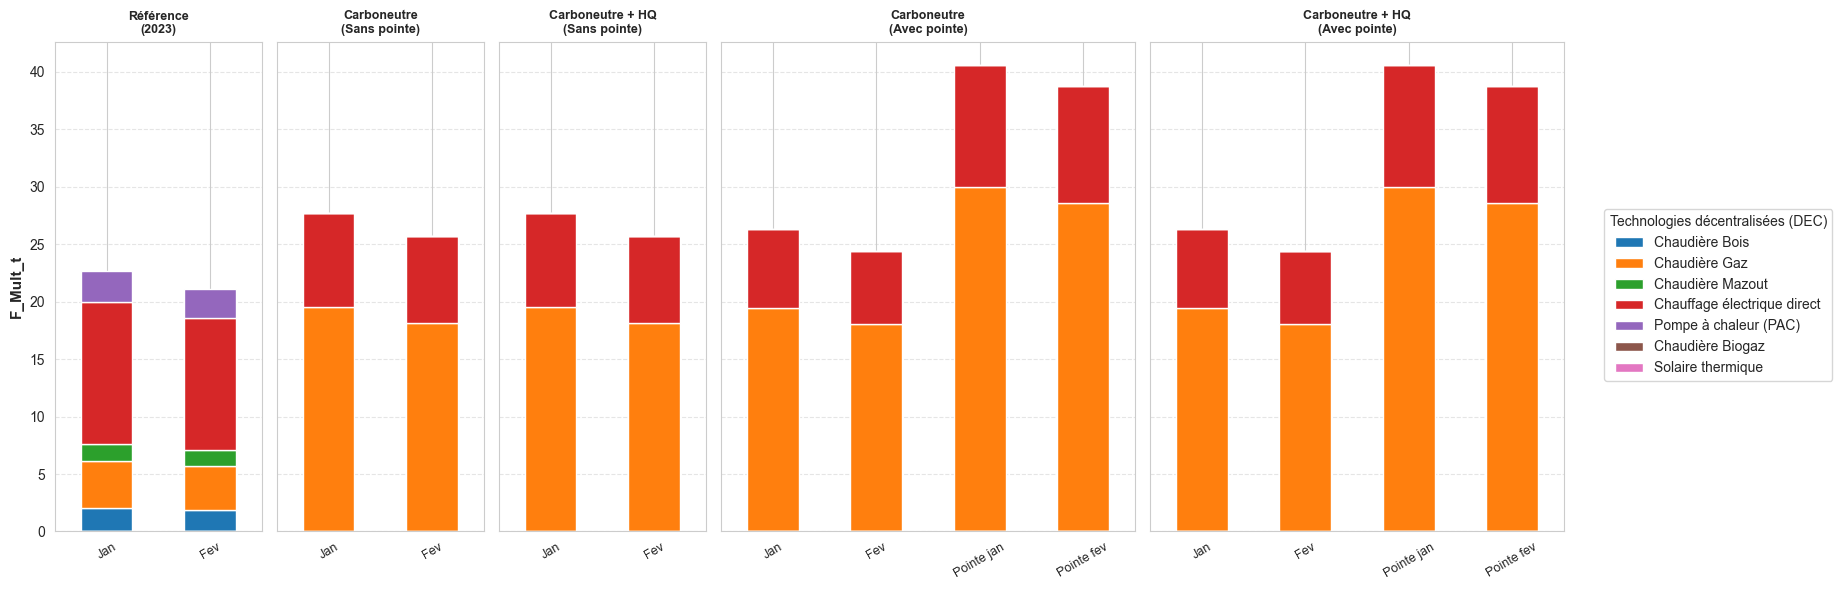

In [81]:
plot_tech_DEC_distribution_five_subplots(
    res_2023=results_wo_peaks_2023_update,
    res_wo_carb=results_wo_peaks_2050_carboneutre,
    res_wo_carb_hq=results_wo_peaks_2050_carboneutre_planHQ,
    res_peak_carb=results_peaks_2050_carboneutre,
    res_peak_carb_hq=results_peaks_2050_carboneutre_planHQ,
    period_labels=[f"P{i}" for i in range(1, 15)],
    periods_wo=[1, 2],
    periods_peak=[1, 2, 13, 14]
)

## Analyse de sensibilité - Membranes

In [83]:
# 1. Définir le chemin vers ton fichier sauvegardé
output_dir = '../03_Results'
output_path = os.path.join(output_dir, 'results_peaks_2050_carboneutre_AS_membrane.pkl')

# 2. Charger le dictionnaire complet en mémoire
with open(output_path, 'rb') as f:
    results_peaks_2050_carboneutre_AS_membrane = pickle.load(f)

Chargement des résultats depuis : ../03_Results\results_peaks_2050_carboneutre_AS_membrane.pkl...


In [ ]:
results_peaks_2050_carboneutre_AS_membrane

In [86]:
import pandas as pd

# 1. Initialiser un dictionnaire pour collecter les DataFrames de chaque scénario
ressources_par_scenario = {}

# 2. Boucler sur chaque scénario de ton dictionnaire d'analyse de sensibilité
for nom_scenario, res in results_peaks_2050_carboneutre_AS_membrane.items():
    # Extraire la variable 'Annual_Res' du scénario courant
    df_res = res.variables['Annual_Res'].copy()

    # Nettoyer en enlevant la colonne 'Run'
    df_res = df_res.drop(columns=['Run'], errors='ignore')

    # Stocker la première colonne restante (les valeurs de consommation)
    ressources_par_scenario[nom_scenario] = df_res.iloc[:, 0]

# 3. Fusionner tous les scénarios dans un unique DataFrame
df_compare_ressources = pd.DataFrame(ressources_par_scenario)

# 4. Trier les colonnes pour avoir l'ordre numérique des f_max (0.0, 2.5, 5.0...)
def extraire_valeur_numerique(nom_colonne):
    return float(nom_colonne.replace('f_max_', ''))

colonnes_triees = sorted(df_compare_ressources.columns, key=extraire_valeur_numerique)
df_compare_ressources = df_compare_ressources[colonnes_triees]

# ==============================================================================
# [NOUVEAU] FILTRAGE DYNAMIQUE
# ==============================================================================
# On calcule l'écart-type sur l'axe des colonnes (axis=1).
# Si std == 0, la valeur est constante sur toutes les itérations.
# On ne garde que les lignes où std > 0 (ceux qui changent selon les colonnes).
df_compare_ressources = df_compare_ressources[df_compare_ressources.std(axis=1) > 0]

# Afficher le DataFrame filtré
df_compare_ressources

,f_max_0.0,f_max_2.5,f_max_5.0,f_max_7.5,f_max_10.0,f_max_12.5,f_max_15.0,f_max_17.5,f_max_20.0,f_max_22.5,f_max_25.0,f_max_27.5,f_max_30.0,f_max_32.5,f_max_35.0
index,,,,,,,,,,,,,,,
BIOMASS_AGRICULTURE_RESIDUAL,27.456717,27.456717,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432,27.558432
BIO_ETHANOL,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371,1.280371
DIESEL,0.000000,0.000000,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510,0.223510
GASOLINE,0.000000,0.000000,0.086722,0.086722,0.086721,0.086722,0.086722,0.086722,0.086722,0.086722,0.086722,0.086722,0.086722,0.086722,0.086722
H2_EHP,6129.202107,6129.202107,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317,2.567317
JETFUEL,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911
LFO,6.333895,6.333895,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541,5.252541
METHANOL,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364
NG_EHP,154328.622394,150124.505762,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409,155547.800409


In [89]:
import pandas as pd

# 1. Initialiser un dictionnaire pour collecter les DataFrames de chaque scénario
f_mult_par_scenario = {}

# 2. Boucler sur chaque scénario de ton dictionnaire d'analyse de sensibilité
for nom_scenario, res in results_peaks_2050_carboneutre_AS_membrane.items():
    # Extraire la variable 'F_Mult' du scénario courant
    df_f_mult = res.variables['F_Mult'].copy()

    # Nettoyer en enlevant la colonne 'Run'
    df_f_mult = df_f_mult.drop(columns=['Run'], errors='ignore')

    # Stocker la première colonne restante (les valeurs de capacité des technologies)
    f_mult_par_scenario[nom_scenario] = df_f_mult.iloc[:, 0]

# 3. Fusionner tous les scénarios dans un unique DataFrame
df_compare_f_mult = pd.DataFrame(f_mult_par_scenario)

# 4. Trier les colonnes pour avoir l'ordre numérique des f_max (0.0, 2.5, 5.0...)
def extraire_valeur_numerique(nom_colonne):
    return float(nom_colonne.replace('f_max_', ''))

colonnes_triees = sorted(df_compare_f_mult.columns, key=extraire_valeur_numerique)
df_compare_f_mult = df_compare_f_mult[colonnes_triees]

# ==============================================================================
# FILTRAGE DYNAMIQUE (Seulement ce qui varie)
# ==============================================================================
# On calcule l'écart-type sur l'axe des colonnes (axis=1).
# On ne garde que les technologies qui s'adaptent (std > 0).
df_compare_f_mult = df_compare_f_mult[df_compare_f_mult.std(axis=1) > 0.01]

# Afficher le DataFrame final pour F_Mult
df_compare_f_mult

,f_max_0.0,f_max_2.5,f_max_5.0,f_max_7.5,f_max_10.0,f_max_12.5,f_max_15.0,f_max_17.5,f_max_20.0,f_max_22.5,f_max_25.0,f_max_27.5,f_max_30.0,f_max_32.5,f_max_35.0
index,,,,,,,,,,,,,,,
AFC,0.000000,0.000000,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684,0.036684
BIOMASS_GAS_FB_H2,0.134807,0.134807,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CARBON_CAPTURE_MEMBRANES,0.000000,2.500000,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820,4.613820
CARBON_CAPTURE_MOF,4.477261,1.864848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CARBON_MINERALIZATION,2.128979,2.015723,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540,2.264540
CO2_STO,0.881619,7.137035,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600,8.368600
DEC_BOILER_GAS,30.131318,30.319014,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771,29.948771
DEC_DIRECT_ELEC,10.536673,10.536705,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215,10.636215
DHN,1.535574,1.394349,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848,1.597848


## Limite capture carbone

In [133]:
# 1. CHARGEMENT DES RÉSULTATS
output_dir = '../03_Results'
output_path = os.path.join(output_dir, 'results_peaks_2050_carboneutre_AS_somme_capture.pkl')
with open(output_path, 'rb') as f:
    tous_les_resultats_capture = pickle.load(f)

# 2. EXTRACTION DE 'Annual_Res'
ressources_par_scenario = {}

for nom_scenario, res in tous_les_resultats_capture.items():
    # Extraire la variable 'Annual_Res' du scénario courant
    df_res = res.variables['Annual_Res'].copy()

    # Nettoyer en enlevant la colonne 'Run'
    df_res = df_res.drop(columns=['Run'], errors='ignore')

    # Stocker la première colonne restante (les valeurs de consommation de la ressource)
    ressources_par_scenario[nom_scenario] = df_res.iloc[:, 0]

# Créer le DataFrame global
df_compare_capture_res = pd.DataFrame(ressources_par_scenario)


# 3. RÉORGANISATION DES COLONNES (Dans l'ordre numérique : 0, 2.5, 5, ..., 40)
# On recrée l'ordre exact des clés générées par le script (ex: 'limite_0.0', 'limite_2.5', etc.)
limites_ordonnees = np.arange(0, 40.1, 2.5).tolist()
ordre_colonnes = [f"limite_{val}" for val in limites_ordonnees]

# On réordonne le DataFrame en s'assurant que les colonnes existent bien
colonnes_existantes = [col for col in ordre_colonnes if col in df_compare_capture_res.columns]
df_compare_capture_res = df_compare_capture_res[colonnes_existantes]

# 4. FILTRAGE DU BRUIT DU SOLVEUR (Seulement ce qui varie)
# Calcul de la différence entre la valeur max et min de chaque ligne
difference_max_min = df_compare_capture_res.max(axis=1) - df_compare_capture_res.min(axis=1)

# Seuil de tolérance (0.01 unité) pour éliminer les lignes constantes ou fixes
seuil_tolerance = 0.01
df_compare_capture_res_filtre = df_compare_capture_res[difference_max_min > seuil_tolerance]

# 5. AFFICHAGE DU RÉSULTAT

print(f"Nombre de ressources affectées par la limite de capture : {len(df_compare_capture_res_filtre)}")
df_compare_capture_res_filtre

Nombre de ressources affectées par la limite de capture : 6


,limite_0.0,limite_10.0,limite_20.0,limite_30.0,limite_40.0
index,,,,,
H2_EHP,5274.106893,5273.772977,5273.439060,5273.105143,5272.771226
METHANOL,5397.223885,5357.223885,5317.223885,5277.223885,5237.223885
NG_EHP,10704.749426,10796.159953,10887.570479,10978.981005,11070.391532
RES_HYDRO,206656.336634,206656.438079,206656.539525,206656.640970,206656.742415
RES_SOLAR,937.133836,937.158877,937.183919,937.208961,937.234003
RES_WIND_ONSHORE,168931.037651,168920.219822,168909.401994,168898.584166,168887.766338


In [98]:
# ==============================================================================
# EXTRACTION DE 'F_Mult'
# ==============================================================================
f_mult_par_scenario = {}

for nom_scenario, res in tous_les_resultats_capture.items():
    # Extraire la variable 'F_Mult' du scénario courant
    df_f_mult = res.variables['F_Mult'].copy()
    # Nettoyer en enlevant la colonne 'Run'
    df_f_mult = df_f_mult.drop(columns=['Run'], errors='ignore')
    # Stocker la première colonne restante (les capacités installées)
    f_mult_par_scenario[nom_scenario] = df_f_mult.iloc[:, 0]
# Créer le DataFrame global
df_compare_capture_f_mult = pd.DataFrame(f_mult_par_scenario)

# ==============================================================================
# RÉORGANISATION DES COLONNES (0, 2.5, 5, ..., 40)
# ==============================================================================
limites_ordonnees = np.arange(0, 40.1, 2.5).tolist()
ordre_colonnes = [f"limite_{val}" for val in limites_ordonnees]

# Réordonner le DataFrame
colonnes_existantes = [col for col in ordre_colonnes if col in df_compare_capture_f_mult.columns]
df_compare_capture_f_mult = df_compare_capture_f_mult[colonnes_existantes]

# ==============================================================================
# FILTRAGE DU BRUIT DU SOLVEUR (Seulement ce qui varie)
# ==============================================================================
# Calcul de la différence entre la valeur max et min de chaque technologie
difference_max_min_f_mult = df_compare_capture_f_mult.max(axis=1) - df_compare_capture_f_mult.min(axis=1)

# Seuil de tolérance (0.01 unité, ex: 10 MW) pour éliminer les techs fixes ou à 0
seuil_tolerance_f_mult = 0.01
df_compare_capture_f_mult_filtre = df_compare_capture_f_mult[difference_max_min_f_mult > seuil_tolerance_f_mult]

# ==============================================================================
# AFFICHAGE DU RÉSULTAT
# ==============================================================================
df_compare_capture_f_mult_filtre

,limite_0.0,limite_10.0,limite_20.0,limite_30.0,limite_40.0
index,,,,,
BUS_CNG,0.098611,0.146817,0.195024,0.243230,0.291437
BUS_CNG_SD,0.098611,0.146817,0.195024,0.243230,0.291437
BUS_EV,0.476093,0.427886,0.379679,0.331473,0.283266
BUS_EV_SD,0.476093,0.427886,0.379679,0.331473,0.283266
HYDRO_STORAGE,12759.373755,12759.625172,12759.876590,12760.128008,12760.379426
METHANOL_FT,0.000000,0.005372,0.010744,0.016116,0.021488
NG_EXP_EH,1.842988,1.848491,1.853995,1.859498,1.865002
NG_EXP_HM,0.000000,0.005802,0.011604,0.017405,0.023207
PLANE_FREIGHT,0.000000,0.137101,0.000000,0.137101,0.000000


In [101]:
# ==============================================================================
# EXTRACTION DE 'Annual_Prod'
# ==============================================================================
annual_prod_par_scenario = {}

for nom_scenario, res in tous_les_resultats_capture.items():
    # Extraire la variable 'Annual_Prod' du scénario courant
    df_prod = res.variables['Annual_Prod'].copy()

    # Nettoyer en enlevant la colonne 'Run'
    df_prod = df_prod.drop(columns=['Run'], errors='ignore')

    # Stocker la première colonne restante (les productions annuelles)
    annual_prod_par_scenario[nom_scenario] = df_prod.iloc[:, 0]

# Créer le DataFrame global
df_compare_capture_annual_prod = pd.DataFrame(annual_prod_par_scenario)


# ==============================================================================
# RÉORGANISATION DES COLONNES (0, 2.5, 5, ..., 40)
# ==============================================================================
limites_ordonnees = np.arange(0, 40.1, 2.5).tolist()
ordre_colonnes = [f"limite_{val}" for val in limites_ordonnees]

# Réordonner le DataFrame
colonnes_existantes = [col for col in ordre_colonnes if col in df_compare_capture_annual_prod.columns]
df_compare_capture_annual_prod = df_compare_capture_annual_prod[colonnes_existantes]


# ==============================================================================
# FILTRAGE DU BRUIT DU SOLVEUR (Seulement ce qui varie)
# ==============================================================================
# Calcul de la différence entre la valeur max et min de chaque technologie
difference_max_min_prod = df_compare_capture_annual_prod.max(axis=1) - df_compare_capture_annual_prod.min(axis=1)

# Seuil de tolérance (0.01 unité) pour éliminer les lignes constantes ou à 0
seuil_tolerance_prod = 1
df_compare_capture_annual_prod_filtre = df_compare_capture_annual_prod[difference_max_min_prod > seuil_tolerance_prod]


# ==============================================================================
# AFFICHAGE DU RÉSULTAT
# ==============================================================================
print(f"Nombre de technologies dont la production varie : {len(df_compare_capture_annual_prod_filtre)}")
df_compare_capture_annual_prod_filtre

Nombre de technologies dont la production varie : 34


,limite_0.0,limite_10.0,limite_20.0,limite_30.0,limite_40.0
index,,,,,
BUS_CNG,256.557022,381.976954,507.396887,632.816819,758.236751
BUS_CNG_SD,256.557022,381.976954,507.396887,632.816819,758.236751
BUS_EV,1238.659424,1113.239492,987.819560,862.399627,736.979695
BUS_EV_SD,1238.659424,1113.239492,987.819560,862.399627,736.979695
CARBON_CAPTURE_MEMBRANES,0.000000,10.000000,20.000000,30.000000,40.000000
EHP_H2_GRID,5274.106893,5273.772977,5273.439060,5273.105143,5272.771226
EHP_NG_GRID,10704.749426,16871.049114,16954.319855,10978.981005,17120.861337
H2_EXP_EH,5274.106893,5273.772977,5273.439060,5273.105143,5272.771226
HP_H2_GRID,32959.693388,32959.359471,32959.025554,32958.691638,32958.357721


## Analyse de sensibilité - Coûts GN

In [90]:
import pickle
import os
import pandas as pd

# ==============================================================================
# 1. CHARGEMENT DES RÉSULTATS
# ==============================================================================
output_dir = '../03_Results'
output_path = os.path.join(output_dir, 'results_peaks_2050_carboneutre_AS_prix_gaz.pkl')

print(f"Chargement des résultats depuis : {output_path}...")
with open(output_path, 'rb') as f:
    tous_les_resultats_gaz = pickle.load(f)

print(f"Chargement réussi ! {len(tous_les_resultats_gaz)} scénarios trouvés.\n")


# ==============================================================================
# 2. EXTRACTION ET EXTRACTION DE 'Annual_Res'
# ==============================================================================
ressources_par_scenario = {}

for nom_scenario, res in tous_les_resultats_gaz.items():
    # Extraire la variable 'Annual_Res' du scénario courant
    df_res = res.variables['Annual_Res'].copy()

    # Nettoyer en enlevant la colonne 'Run'
    df_res = df_res.drop(columns=['Run'], errors='ignore')

    # Stocker la première colonne restante (les valeurs de consommation)
    ressources_par_scenario[nom_scenario] = df_res.iloc[:, 0]

# Créer le DataFrame global
df_compare_gaz_ressources = pd.DataFrame(ressources_par_scenario)


# ==============================================================================
# 3. RÉORGANISATION DES COLONNES (Dans l'ordre logique de variation)
# ==============================================================================
# Liste de l'ordre exact qu'on veut donner à nos colonnes
ordre_colonnes = [
    "gaz_divise_par_2",
    "gaz_facteur_0.75",
    "gaz_prix_de_base",
    "gaz_facteur_1.25",
    "gaz_facteur_1.50",
    "gaz_facteur_1.75",
    "gaz_multiplie_par_2"
]

# Réordonner le DataFrame (en s'assurant que toutes les colonnes existent)
colonnes_existantes = [col for col in ordre_colonnes if col in df_compare_gaz_ressources.columns]
df_compare_gaz_ressources = df_compare_gaz_ressources[colonnes_existantes]


# ==============================================================================
# 4. FILTRAGE DU BRUIT DU SOLVEUR (Seulement ce qui varie)
# ==============================================================================
# Calcul de la différence entre la valeur max et min de chaque ligne
difference_max_min = df_compare_gaz_ressources.max(axis=1) - df_compare_gaz_ressources.min(axis=1)

# Seuil de tolérance (0.01 unité) pour éliminer les ressources fixes ou à 0
seuil_tolerance = 0.01
df_compare_gaz_ressources_filtre = df_compare_gaz_ressources[difference_max_min > seuil_tolerance]


# ==============================================================================
# 5. AFFICHAGE DU RÉSULTAT
# ==============================================================================
print(f"Nombre de ressources impactées par le prix du gaz : {len(df_compare_gaz_ressources_filtre)}")
df_compare_gaz_ressources_filtre

Chargement des résultats depuis : ../03_Results\results_peaks_2050_carboneutre_AS_prix_gaz.pkl...
Chargement réussi ! 7 scénarios trouvés.

Nombre de ressources impactées par le prix du gaz : 14


,gaz_divise_par_2,gaz_facteur_0.75,gaz_prix_de_base,gaz_facteur_1.25,gaz_facteur_1.50,gaz_facteur_1.75,gaz_multiplie_par_2
index,,,,,,,
BIOMASS_AGRICULTURE_RESIDUAL,25.063283,28.799934,27.558432,27.558432,27.558432,27.558432,27.902779
DIESEL,0.000000,0.000000,0.223510,0.223510,0.289996,0.289996,3.167089
ELECTRICITY_OTHER,0.000000,0.000000,0.000000,0.000000,2480.543888,2480.492950,2490.931127
GASOLINE,0.000000,0.000000,0.086722,0.086722,0.112519,0.112519,1.228831
H2_EHP,0.000000,0.000000,2.567317,7132.975000,7447.846069,7447.846069,20365.175459
JETFUEL,17364.720532,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911,17381.958911
LFO,24.060662,24.573332,5.252541,4.383370,2.099909,4.800260,0.000000
METHANOL,1.848364,1.848364,1.848364,1.848364,1.848364,1.848364,0.000000
NG_EHP,205602.362283,200806.108026,155438.803287,144525.140492,134333.156788,87753.991232,43148.195974


In [82]:
results_peaks_2050_carboneutre.parameters['c_p_t'].loc['NEW_HYDRO_DAM']

,c_p_t,Run
index1,,
1,0.758,0
2,0.742,0
3,0.623,0
4,0.475,0
5,0.416,0
6,0.455,0
7,0.483,0
8,0.484,0
9,0.429,0


In [73]:
results_wo_peaks_2050_carboneutre.variables['Monthly_Prod'].loc['WIND_ONSHORE']

,Monthly_Prod,Run
index1,,
1,7559.773566,0
2,7563.556077,0
3,8093.518134,0
4,7452.426488,0
5,6784.593368,0
6,5953.496515,0
7,5453.853190,0
8,4995.729522,0
9,6417.953689,0


In [69]:
results_peaks_2050_carboneutre.parameters['end_uses_demand_year'].loc['HEAT_LOW_T_SH']
#results_wo_peaks_2050_carboneutre.parameters['end_uses_demand_year'].loc['HEAT_LOW_T_SH']


,end_uses_demand_year,Run
index1,,
AGRICULTURE,1095.580000,0
EXPORT,0.000000,0
HOUSEHOLDS,61721.780651,0
INDUSTRY,3725.021431,0
SERVICES,28682.241265,0
TRANSPORTATION,0.000000,0


In [67]:
results_peaks_2050_carboneutre.parameters['heating_month']
results_wo_peaks_2050_carboneutre.parameters['heating_month']

,heating_month,Run
1,0.197976,0
2,0.164593,0
3,0.142100,0
4,0.031900,0
5,0.000000,0
6,0.000000,0
7,0.000000,0
8,0.000000,0
9,0.014700,0
10,0.089800,0


In [ ]:
results_peaks_2050_carboneutre.parameters['heating_month'].loc
results_wo_peaks_2050_carboneutre.variables['heating_month']

In [68]:
0.1984 - 0.197976

0.00042399999999997995